In [128]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import platform
from scipy import stats
import pingouin as pg
import scikit_posthocs as sp
import cliffs_delta
from collections import defaultdict
import math

warnings.filterwarnings('ignore')
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [129]:
# 그래프 3종
def plot_cluster_distribution_triplet(
    df,
    value_col: str,
    cluster_col: str = '군집',
    figsize=(15, 5),
    palette="Set2",
    order=None,
    bar_ylim=None,          # 예: (5, 10)
    title_prefix=None,      # 예: "정류장_접근성"
    show=True
):
    """
    군집별 분포를 Box/Violin/Bar(평균) 3개 그래프로 한 번에 그리는 함수.

    Parameters
    ----------
    df : pd.DataFrame
    cluster_col : str
        군집 컬럼명 (예: '군집')
    value_col : str
        값 컬럼명 (예: '정류장_접근성')
    figsize : tuple
        전체 figure 크기
    palette : str or list
        seaborn 팔레트
    order : list or None
        x축 군집 순서 지정 (예: [0,1,2,3,4,5])
    bar_ylim : tuple or None
        barplot y축 범위 (예: (5,10))
    title_prefix : str or None
        제목 앞에 붙일 텍스트 (기본은 value_col 사용)
    show : bool
        True면 plt.show() 실행

    Returns
    -------
    fig, axes
    """

    if title_prefix is None:
        title_prefix = value_col

    fig, axes = plt.subplots(1, 3, figsize=figsize)

    # -----------------------------
    # 1) BoxPlot
    # -----------------------------
    sns.boxplot(
        x=cluster_col, y=value_col, data=df,
        ax=axes[0], palette=palette, order=order
    )
    axes[0].set_title(f'{title_prefix} 군집별 분포 (Boxplot)', fontweight='bold')
    axes[0].set_xlabel(cluster_col)
    axes[0].set_ylabel(value_col)

    # -----------------------------
    # 2) ViolinPlot
    # -----------------------------
    sns.violinplot(
        x=cluster_col, y=value_col, data=df,
        ax=axes[1], palette=palette, order=order
    )
    axes[1].set_title(f'{title_prefix} 군집별 분포 (Violinplot)', fontweight='bold')
    axes[1].set_xlabel(cluster_col)
    axes[1].set_ylabel(value_col)

    # -----------------------------
    # 3) BarPlot (mean)
    # -----------------------------
    sns.barplot(
        x=cluster_col, y=value_col, data=df,
        ax=axes[2], palette=palette, order=order,
        estimator="mean", errorbar="ci"
    )
    axes[2].set_title(f'{title_prefix} 군집별 평균 (Barplot)', fontweight='bold')
    axes[2].set_xlabel(cluster_col)
    axes[2].set_ylabel(value_col)

    if bar_ylim is not None:
        axes[2].set_ylim(*bar_ylim)

    fig.tight_layout()

    if show:
        plt.show()


# 군집별 히스토그램
def histogram_by_cluster(
    cluster_list,
    value_col: str,
    ncols: int = 3,
    figsize=(15, 8),
    bins=30,
    color='#7ae07a',
    alpha=0.7,
    suptitle: str = None,
    show=True
):
    """
    군집별 히스토그램을 한 Figure에 그리는 함수.

    Parameters
    ----------
    cluster_list : list of pd.DataFrame
        군집별로 나뉜 DataFrame 리스트
    value_col : str
        히스토그램을 그릴 컬럼명 (예: '전망')
    ncols : int
        subplot 열 개수
    figsize : tuple
        전체 figure 크기
    bins : int or sequence
        히스토그램 bin 개수
    color : str or None
        막대 색상 (None이면 matplotlib 기본)
    alpha : float
        투명도
    suptitle : str or None
        전체 제목
    show : bool
        True면 plt.show()

    Returns
    -------
    fig, axes
    """

    n_clusters = len(cluster_list)
    nrows = math.ceil(n_clusters / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = axes.flatten()

    for i, df_cluster in enumerate(cluster_list):
        data = df_cluster[value_col].dropna()

        if len(data) == 0:
            axes[i].text(
                0.5, 0.5,
                "No data",
                ha="center", va="center",
                transform=axes[i].transAxes
            )
            axes[i].set_title(f"군집 {i}")
            axes[i].axis("off")
            continue

        axes[i].hist(data, bins=bins, color=color, alpha=alpha)
        axes[i].set_title(f"군집 {i}")
        axes[i].set_xlabel(value_col)
        axes[i].set_ylabel("Count")

    # 남는 subplot 비활성화
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    if suptitle is None:
        suptitle = f"군집별 {value_col} 히스토그램"

    plt.suptitle(suptitle)
    plt.tight_layout()

    if show:
        plt.show()

# 군집별 QQ플랏
def qqplot_by_cluster(
    cluster_list,
    value_col: str,
    ncols: int = 3,
    figsize=(15, 8),
    dist=stats.norm,
    suptitle: str = None,
    show=True,
    point_color: str = '#7ae07a',     # 🔥 추가: 점 색
    line_color: str = '#333333',      # 🔥 추가: 기준선 색
    point_alpha: float = 0.6,
    line_width: float = 2.0
):
    """
    군집별 Q-Q plot(정규성 시각 점검)을 한 Figure에 그리는 함수
    """

    import math
    import matplotlib.pyplot as plt
    from scipy import stats

    n_clusters = len(cluster_list)
    nrows = math.ceil(n_clusters / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = axes.flatten()

    for i, df_cluster in enumerate(cluster_list):
        ax = axes[i]
        data = df_cluster[value_col].dropna()

        if len(data) < 3:
            ax.text(
                0.5, 0.5,
                "Not enough data",
                ha="center", va="center",
                transform=ax.transAxes
            )
            ax.set_title(f"군집 {i}")
            ax.axis("off")
            continue

        # === Q-Q plot ===
        stats.probplot(data, dist=dist, plot=ax)

        # === 🔥 색상 커스터마이즈 ===
        # ax.lines[0] : 데이터 점
        ax.lines[0].set_markerfacecolor(point_color)
        ax.lines[0].set_markeredgecolor(point_color)
        ax.lines[0].set_alpha(point_alpha)

        # ax.lines[1] : 기준선
        ax.lines[1].set_color(line_color)
        ax.lines[1].set_linewidth(line_width)

        ax.set_title(f"군집 {i}")
        ax.set_xlabel("")
        ax.set_ylabel("")

    # 남는 subplot 제거
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    if suptitle is None:
        suptitle = f"군집별 {value_col} 정규성 확인 (Q–Q Plot)"

    plt.suptitle(suptitle)
    plt.tight_layout()

    if show:
        plt.show()

# 왜도, 첨도

def skew_kurt(data, col):
    skew = stats.skew(data[col])
    kurt = stats.kurtosis(data[col], fisher = True)

    is_skew_ok = abs(skew) < 2
    is_kurt_ok = abs(kurt) < 7

    print("=" * 15, '군집',data['군집'].iloc[0], "=" * 20)
    print(f"  - 왜도(Skew): {skew:.4f} {'(적절)' if is_skew_ok else '(주의)'}")
    print(f"  - 첨도(Kurt): {kurt:.4f} {'(적절)' if is_kurt_ok else '(주의)'}")


def welch_anova_report(
    df,
    dv_col: str,
    target_cluster=None, 
    group_col: str = "군집",
    alpha: float = 0.05, 
    direction: str = "higher",  # "higher" | "lower" | "different"
    show_table: bool = True
):
    """
    Welch ANOVA 실행 + 가설 문장 + 유의성/효과크기(np2) 해석 출력

    Parameters
    ----------
    df : DataFrame
    dv_col : str
        종속변수 컬럼명 (예: '사진', '전망' 등)
    group_col : str
        집단(군집) 컬럼명 (기본 '군집')
    alpha : float
        유의수준
    target_cluster : any
        특정 군집를 가설문에 명시하고 싶을 때 (예: 2)
    direction : str
        "higher"(타 군집보다 높다), "lower"(낮다), "different"(차이가 있다)
    show_table : bool
        결과 테이블을 display할지 여부
    """

    # ---- 기본 검증 ----
    if dv_col not in df.columns:
        raise KeyError(f"dv_col='{dv_col}' 컬럼이 df에 없습니다.")
    if group_col not in df.columns:
        raise KeyError(f"group_col='{group_col}' 컬럼이 df에 없습니다.")

    # ---- 가설 출력 문구 구성 ----
    if target_cluster is None:
        h0 = f"H0 : {group_col} 간 평균 {dv_col} 점수는 통계적으로 유의미한 차이가 없다."
        h1 = f"H1 : {group_col} 간 평균 {dv_col} 점수는 통계적으로 유의미한 차이가 있다."
    else:
        h0 = f"H0 : {group_col} {target_cluster}와 타 {group_col} 간의 평균 {dv_col} 점수는 통계적으로 유의미한 차이가 없다."
        if direction == "higher":
            h1 = f"H1 : {group_col} {target_cluster}의 평균 {dv_col} 점수는 타 {group_col}의 평균보다 통계적으로 유의미하게 높다."
        elif direction == "lower":
            h1 = f"H1 : {group_col} {target_cluster}의 평균 {dv_col} 점수는 타 {group_col}의 평균보다 통계적으로 유의미하게 낮다."
        else:
            h1 = f"H1 : {group_col} {target_cluster}의 평균 {dv_col} 점수는 타 {group_col}와 통계적으로 유의미한 차이가 있다."

    print(h0)
    print(h1)

    # ---- Welch's ANOVA ----
    anova_res = pg.welch_anova(dv=dv_col, between=group_col, data=df)

    if show_table:
        display(anova_res)

    # ---- p값 / 효과크기 ----
    p = float(anova_res["p-unc"].iloc[0])
    np2 = float(anova_res["np2"].iloc[0]) if "np2" in anova_res.columns else None

    if p <= alpha:
        print("ANOVA 유의미")
        print("사후검정 고려")

        if np2 is None:
            print("효과크기(np2) 컬럼이 결과에 없습니다.")
        else:
            if np2 < 0.01:
                eff = "매우 작은 효과"
            elif np2 < 0.06:
                eff = "작은 효과"
            elif np2 < 0.14:
                eff = "중간 효과"
            else:
                eff = "큰 효과"
            print(f"효과크기 : {eff} (np2={np2:.4f})")

    else:
        print("가설기각")  # (= 유의하지 않음)

def force_target_as_A_full(gh_df, target_cluster):
    """
    Games-Howell 결과에서 target_cluster가 항상 A가 되도록 정규화.
    - A/B swap
    - mean(A) <-> mean(B) swap
    - diff, T, hedges(있으면) 부호 반전
    - se, df, pval 등은 그대로
    """
    gh = gh_df.copy()

    # target이 B에 있는 행(= A가 target이 아닌 행)
    mask = gh["A"] != target_cluster

    # 1) A,B swap
    gh.loc[mask, ["A", "B"]] = gh.loc[mask, ["B", "A"]].values

    # 2) mean(A), mean(B) swap (컬럼이 있을 때만)
    meanA, meanB = "mean(A)", "mean(B)"
    if meanA in gh.columns and meanB in gh.columns:
        gh.loc[mask, [meanA, meanB]] = gh.loc[mask, [meanB, meanA]].values

    # 3) 부호 뒤집어야 하는 값들: diff, T, effect size(hedges 등)
    sign_flip_cols = []
    for col in ["diff", "T", "t", "hedges", "Hedges", "g", "d"]:
        if col in gh.columns:
            sign_flip_cols.append(col)

    for col in sign_flip_cols:
        gh.loc[mask, col] = -gh.loc[mask, col]

    return gh

def games_howell_target_test(
    df,
    dv_col: str,
    target_cluster = None,
    group_col: str = "군집",
    alpha: float = 0.05,
    verbose: bool = True,
    show_table: bool = True
):
    """
    Games-Howell 사후검정에서 특정 군집(target_cluster)가
    타 군집보다
    - 유의미하게 높은지
    - 유의미하게 낮은지
    - 아니면 혼합/비유의인지
    판정
    """

    # ---- 컬럼 체크 ----
    if dv_col not in df.columns:
        raise KeyError(f"'{dv_col}' 컬럼이 df에 없습니다.")
    if group_col not in df.columns:
        raise KeyError(f"'{group_col}' 컬럼이 df에 없습니다.")

    # ---- Games-Howell ----
    gh = pg.pairwise_gameshowell(
        dv=dv_col,
        between=group_col,
        data=df
    )

    # ---- target_cluster 관련 비교만 ----
    cond = (gh["A"] == target_cluster) | (gh["B"] == target_cluster)
    gh_t = gh[cond].copy()
    gh_t = force_target_as_A_full(gh_t, target_cluster)

    # ---- 유의성 ----
    is_sig = gh_t["pval"] < alpha

    # ---- 방향성 ----
    is_sig = gh_t["pval"] < alpha
    is_higher = gh_t["diff"] > 0
    is_lower  = gh_t["diff"] < 0

    all_higher = (is_sig & is_higher).all()
    all_lower  = (is_sig & is_lower).all()

    if verbose:
        if all_higher:
            print(
                f"가설채택: {group_col} {target_cluster}가 "
                f"타 {group_col}에 비해 {dv_col} 평균 점수가 "
                f"통계적으로 유의미하게 높음"
            )
        elif all_lower:
            print(
                f"가설채택: {group_col} {target_cluster}가 "
                f"타 {group_col}에 비해 {dv_col} 평균 점수가 "
                f"통계적으로 유의미하게 낮음"
            )
        else:
            print(
                f"가설기각: {dv_col}에 대해 "
                f"유의하지 않거나, 높고 낮음이 혼재"
            )

    if show_table:
        display(gh_t)

    # 상태 반환 (분기용)
    if all_higher:
        status = "higher"
    elif all_lower:
        status = "lower"
    else:
        status = "mixed_or_nonsig"


# 비모수 검정
def kruskal_vs_others_with_eta(
        df, 
        value_col : str,
        target_cluster,
        cluster_col : str = '군집'
        ):
    """
    기준 군집(target_cluster)과 나머지 군집 전체를 비교하는
    Kruskal–Wallis 검정 + 효과크기(η²) 계산 함수

    Parameters
    ----------
    df : pandas.DataFrame
        전체 데이터프레임
    value_col : str
        비교할 값 컬럼명 (예: '정류장_접근성')
    cluster_col : str
        군집 컬럼명 (예: '군집')
    target_cluster : int or str
        기준이 되는 군집 번호

    Returns
    -------
    dict
        {
            'H': Kruskal H 통계량,
            'p_value': p-value,
            'eta_sq': 효과크기 η²,
            'n_total': 전체 표본 수,
            'k': 그룹 수
        }
    """

    # -----------------------------
    # 1) 그룹 분리
    # -----------------------------
    c_target = df[df[cluster_col] == target_cluster][value_col].dropna()
    c_others = df[df[cluster_col] != target_cluster][value_col].dropna()

    if len(c_target) == 0 or len(c_others) == 0:
        raise ValueError("기준 군집 또는 비교군에 데이터가 없습니다.")

    # -----------------------------
    # 2) Kruskal–Wallis 검정
    # -----------------------------
    H, p = stats.kruskal(c_target, c_others)

    # -----------------------------
    # 3) 효과 크기 η² 계산
    # -----------------------------
    k = df[cluster_col].nunique()   # 군집 수
    n = len(df)

    eta_sq = (H - k + 1) / (n - k)

    # -----------------------------
    # 4) 결과 정리
    # -----------------------------
    result = {
        "H": H,
        "p_value": p,
        "eta_sq": eta_sq,
        "n_total": n,
        "k": k
    }
    print(f'비모수 검정 (Kruskal-Wallis) 결과\n')
    print(f"H-statistic = {H:.3f}")
    print(f"p-value     = {p:.10f}")
    print(f"효과크기(η²) = {eta_sq:.3f}")

def compute_cliffs_from_pairs(df, value_col, cluster_col, sig_pairs):
    """
    df          : DataFrame
    value_col   : 비교할 수치형 변수 (예: '관광인프라점수')
    cluster_col : 군집 컬럼명 (예: 'Cluster')
    sig_pairs   : [(i, j, p_value), ...]
    
    return:
        {(i, j): (delta, size)}
    """
    effect_sizes = {}

    for i, j, _ in sig_pairs:
        g1 = df[df[cluster_col] == i][value_col]
        g2 = df[df[cluster_col] == j][value_col]

        delta, size = cliffs_delta.cliffs_delta(g1, g2)
        effect_sizes[(i, j)] = (round(delta, 3), size)

    return effect_sizes

def rank_clusters_from_cliffs(cliffs_dict):
    """
    cliffs_dict: {(i, j): (delta, size)}
    return: DataFrame with score, wins, losses, rank
    """

    scores = defaultdict(float)
    wins = defaultdict(int)
    losses = defaultdict(int)

    for (i, j), (delta, size) in cliffs_dict.items():
        weight = abs(delta)

        if delta > 0:
            # i > j
            scores[i] += weight
            scores[j] -= weight
            wins[i] += 1
            losses[j] += 1
        elif delta < 0:
            # j > i
            scores[j] += weight
            scores[i] -= weight
            wins[j] += 1
            losses[i] += 1

    clusters = sorted(set([c for pair in cliffs_dict for c in pair]))

    df_rank = pd.DataFrame({
        "Cluster": clusters,
        "Score": [scores[c] for c in clusters],
        "Wins": [wins[c] for c in clusters],
        "Losses": [losses[c] for c in clusters],
    })

    df_rank = df_rank.sort_values("Score", ascending=False).reset_index(drop=True)
    df_rank["Rank"] = df_rank.index + 1

    return df_rank

def dunn_and_cliffs_target_only(
    df,
    value_col: str,
    target_cluster,
    cluster_col: str = '군집',
    p_adjust: str = "holm",
    alpha: float = 0.05,
    show_target_vs_all: bool = True,
    float_format: str = "{:.4f}"
):
    """
    Dunn 사후검정 + (유의한 pair의) Cliff's delta 계산 후,
    'target_cluster'가 포함된 pair만 effect_sizes로 반환하고
    해당 결과로 rank_df까지 만들어 반환.

    필요 함수:
      - compute_cliffs_from_pairs(df, value_col, cluster_col, sig_pairs)
      - rank_clusters_from_cliffs(effect_sizes)

    Returns
    -------
    dict with keys:
      - dunn: Dunn p-value matrix (DataFrame)
      - sig_pairs_all: 전체 유의 pair 리스트 [(i,j,p), ...]
      - sig_pairs_target: target 포함 유의 pair 리스트
      - effect_sizes_target: target 포함 effect size dict {(i,j):(delta, label), ...}
      - rank_df_target: target 포함 effect size로 만든 rank df
    """

    # 1) Dunn test
    dunn = sp.posthoc_dunn(
        df,
        val_col=value_col,
        group_col=cluster_col,
        p_adjust=p_adjust
    )

    # 2) 유의 pair 전체 추출 (상삼각)
    sig_pairs_all = []
    for i in dunn.index:
        for j in dunn.columns:
            if i < j and dunn.loc[i, j] < alpha:
                sig_pairs_all.append((i, j, float(dunn.loc[i, j])))

    # 3) target이 포함된 pair만 필터
    sig_pairs_target = [
        (i, j, p) for (i, j, p) in sig_pairs_all
        if (i == target_cluster) or (j == target_cluster)
    ]

    # 4) Cliff's delta: 전체(랭킹용) + target-only(출력용) 둘 다 계산
    effect_sizes_all = compute_cliffs_from_pairs(
        df=df,
        value_col=value_col,
        cluster_col=cluster_col,
        sig_pairs=sig_pairs_all
    )

    effect_sizes_target = compute_cliffs_from_pairs(
        df=df,
        value_col=value_col,
        cluster_col=cluster_col,
        sig_pairs=sig_pairs_target
    )

    # 5) rank_df는 전체 effect size로
    rank_df = rank_clusters_from_cliffs(effect_sizes_all)

    # 6) 보기 좋게 출력 (옵션)
    pd.set_option("display.float_format", float_format.format)

    if show_target_vs_all:
        print("=== Dunn's Test (비모수 사후검정) 결과 ===")
        print(f"[{value_col}] / p_adjust={p_adjust} / alpha={alpha}")
        print(f"\n군집 {target_cluster} vs Others:")
        print(dunn.loc[target_cluster, :])

        print("\n=== Cliff's delta (target 포함 유의 pair만) ===")
        display(effect_sizes_target)

        print("\n=== Rank (전체 유의 pair 기반, 모든 군집 포함) ===")
        display(rank_df)


In [130]:
df = pd.read_csv("df_하이킹_유클리드_6.csv")

In [131]:
cluster_0 = df[df['군집'] == 0]
cluster_1 = df[df['군집'] == 1]
cluster_2 = df[df['군집'] == 2]
cluster_3 = df[df['군집'] == 3]
cluster_4 = df[df['군집'] == 4]
cluster_5 = df[df['군집'] == 5]

cluster_list = [cluster_0, cluster_1, cluster_2, cluster_3, cluster_4, cluster_5]

# 군집 2 (전망, 사진)

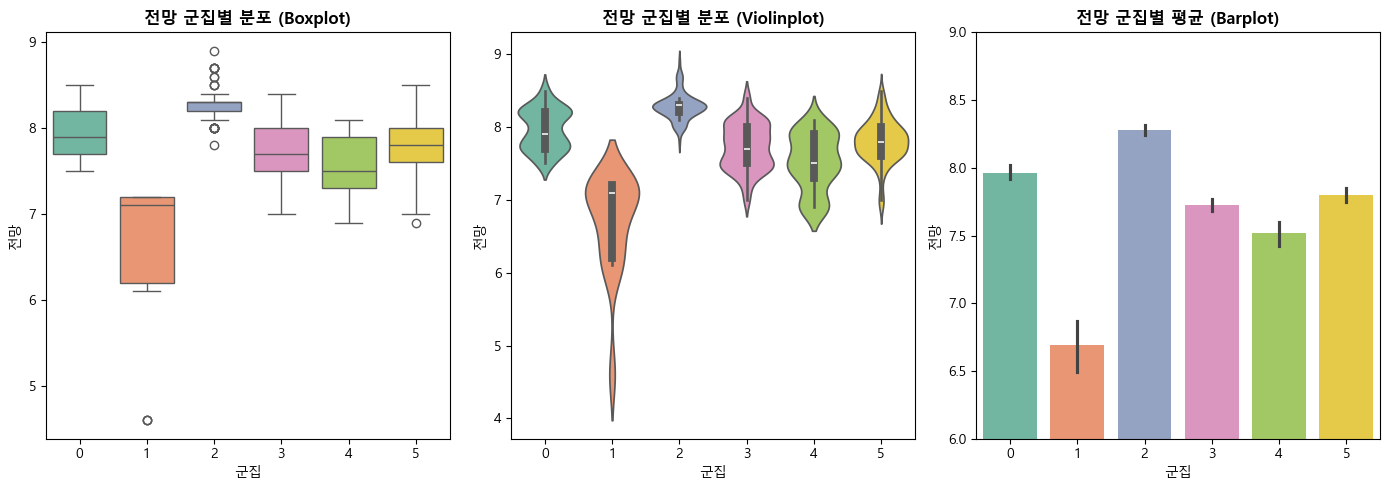

In [132]:
# ===================================================================
# H0 : 군집 2와 타 군집 간의 평균 전망 점수는 통계적으로 유의미한 차이가 없다.
# H1 : 군집 2의 평균 전망 점수는 타 군집의 평균보다 통계적으로 유의미하게 높다.
# ===================================================================

plot_cluster_distribution_triplet(
    df=df,
    value_col='전망',
    figsize=(14, 5),
    palette="Set2",
    bar_ylim=(6, 9)
)

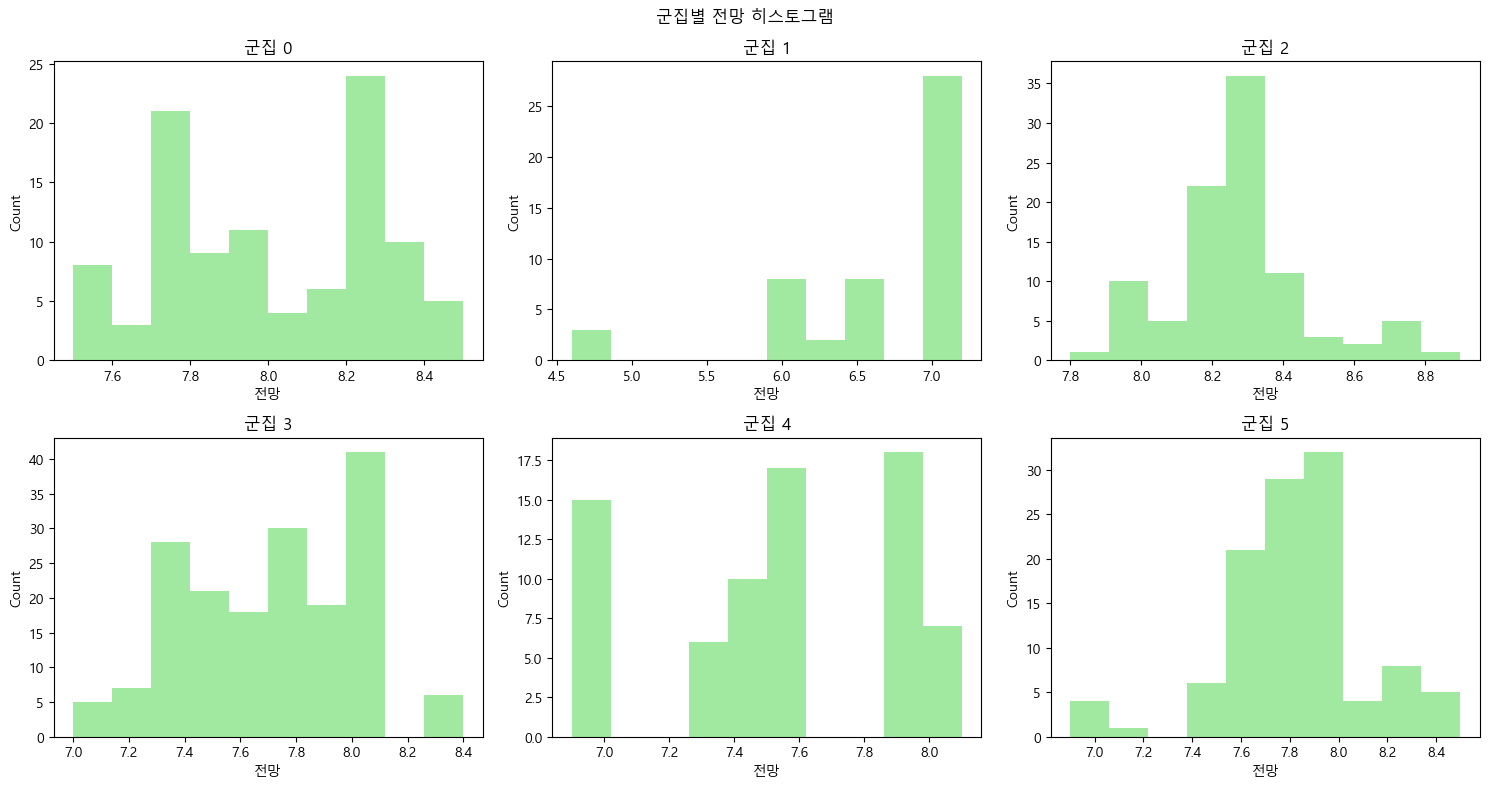

In [133]:
#------------------------------------------------------------------------
# Hist
#------------------------------------------------------------------------

histogram_by_cluster(
    cluster_list,
    value_col='전망',
    figsize=(15, 8),
    bins = 10
)

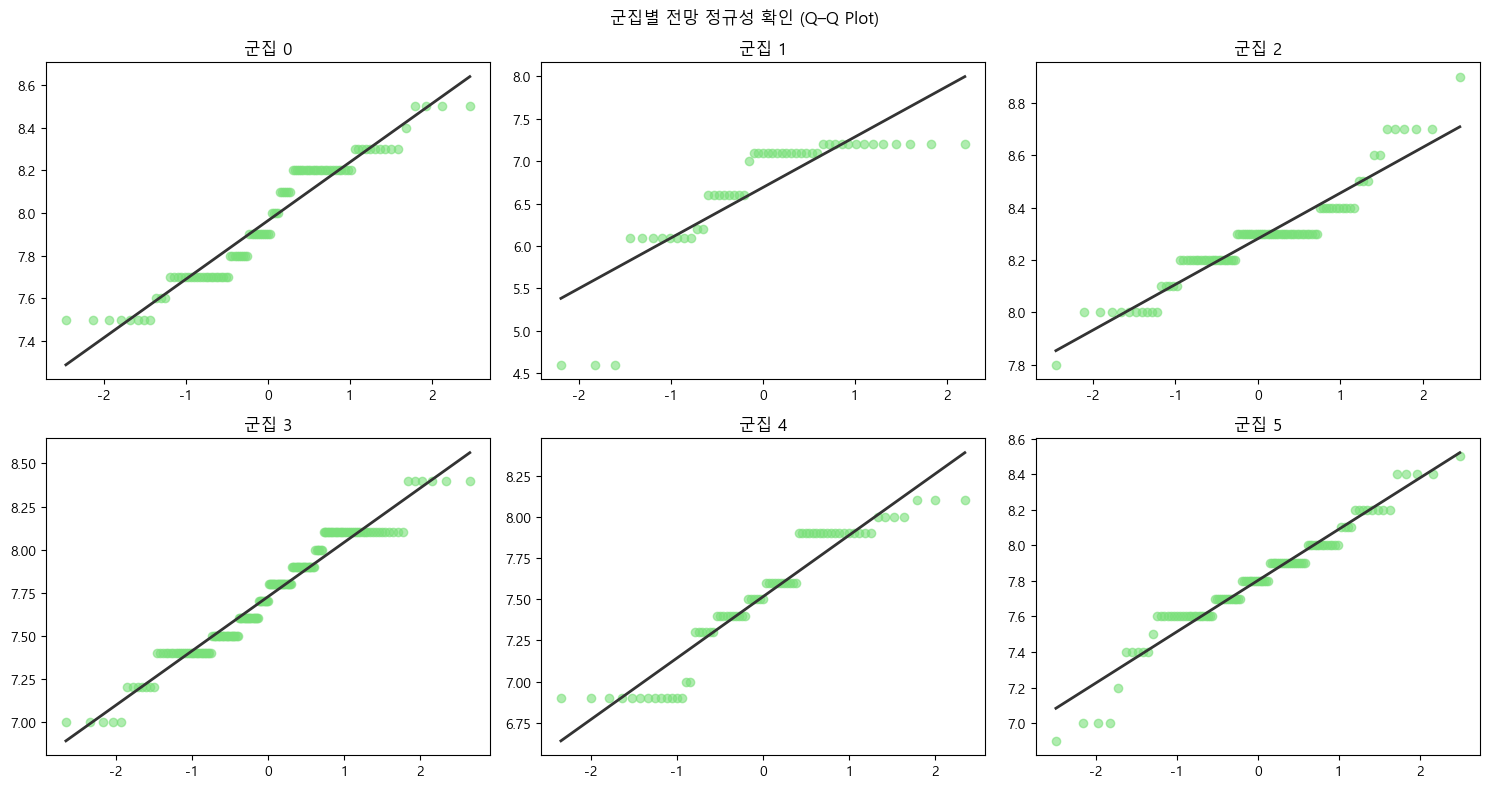

In [134]:
#------------------------------------------------------------------------
# Q - Q Plot
#------------------------------------------------------------------------

qqplot_by_cluster(
    cluster_list,
    value_col='전망',
    figsize=(15, 8),
)

In [135]:
# 전망

for i in cluster_list:
    skew_kurt(i, '전망')
    print('')

=============== 군집 0 ====================
  - 왜도(Skew): 0.0128 (적절)
  - 첨도(Kurt): -1.1660 (적절)

=============== 군집 1 ====================
  - 왜도(Skew): -1.7683 (적절)
  - 첨도(Kurt): 2.8900 (적절)

=============== 군집 2 ====================
  - 왜도(Skew): 0.6145 (적절)
  - 첨도(Kurt): 1.5030 (적절)

=============== 군집 3 ====================
  - 왜도(Skew): -0.0473 (적절)
  - 첨도(Kurt): -0.6051 (적절)

=============== 군집 4 ====================
  - 왜도(Skew): -0.3189 (적절)
  - 첨도(Kurt): -1.0515 (적절)

=============== 군집 5 ====================
  - 왜도(Skew): -0.4147 (적절)
  - 첨도(Kurt): 1.1385 (적절)



In [136]:
#------------------------------------------------------------------------
# 모수검정 시작(ANOVA)
#------------------------------------------------------------------------

welch_anova_report(df, '전망', 2)

H0 : 군집 2와 타 군집 간의 평균 전망 점수는 통계적으로 유의미한 차이가 없다.
H1 : 군집 2의 평균 전망 점수는 타 군집의 평균보다 통계적으로 유의미하게 높다.


,Source,ddof1,ddof2,F,p-unc,np2
0,군집,5,218.2311,138.0878,0.0000,0.5635


ANOVA 유의미
사후검정 고려
효과크기 : 큰 효과 (np2=0.5635)


In [137]:
#------------------------------------------------------------------------
# 효과크기 Games-Howell
#------------------------------------------------------------------------

games_howell_target_test(df, '전망', 2)

가설채택: 군집 2가 타 군집에 비해 전망 평균 점수가 통계적으로 유의미하게 높음


,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
1,2,0,8.2812,7.9644,0.3169,0.0333,9.5028,172.4158,0.0000,1.3353
5,2,1,8.2812,6.6898,1.5915,0.0990,16.0704,51.4825,0.0000,3.7584
9,2,3,8.2812,7.7257,0.5555,0.0303,18.3052,268.6744,0.0000,1.9932
10,2,4,8.2812,7.5151,0.7662,0.0485,15.7974,96.3512,0.0000,2.6650
11,2,5,8.2812,7.8018,0.4794,0.0333,14.3823,185.1470,0.0000,1.9417


---

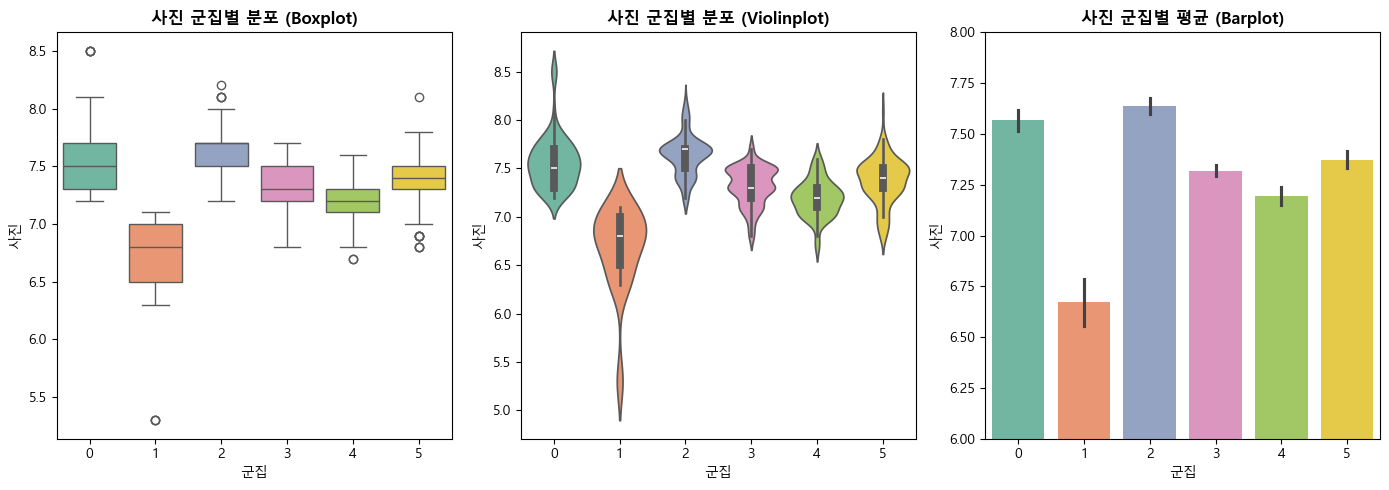

In [138]:
# ===================================================================
# H0 : 군집 2와 타 군집 간의 평균 사진 점수는 통계적으로 유의미한 차이가 없다.
# H1 : 군집 2의 평균 사진 점수는 타 군집의 평균보다 통계적으로 유의미하게 높다.
# ===================================================================

plot_cluster_distribution_triplet(
    df=df,
    value_col='사진',
    figsize=(14, 5),
    palette="Set2",
    bar_ylim=(6, 8)
)


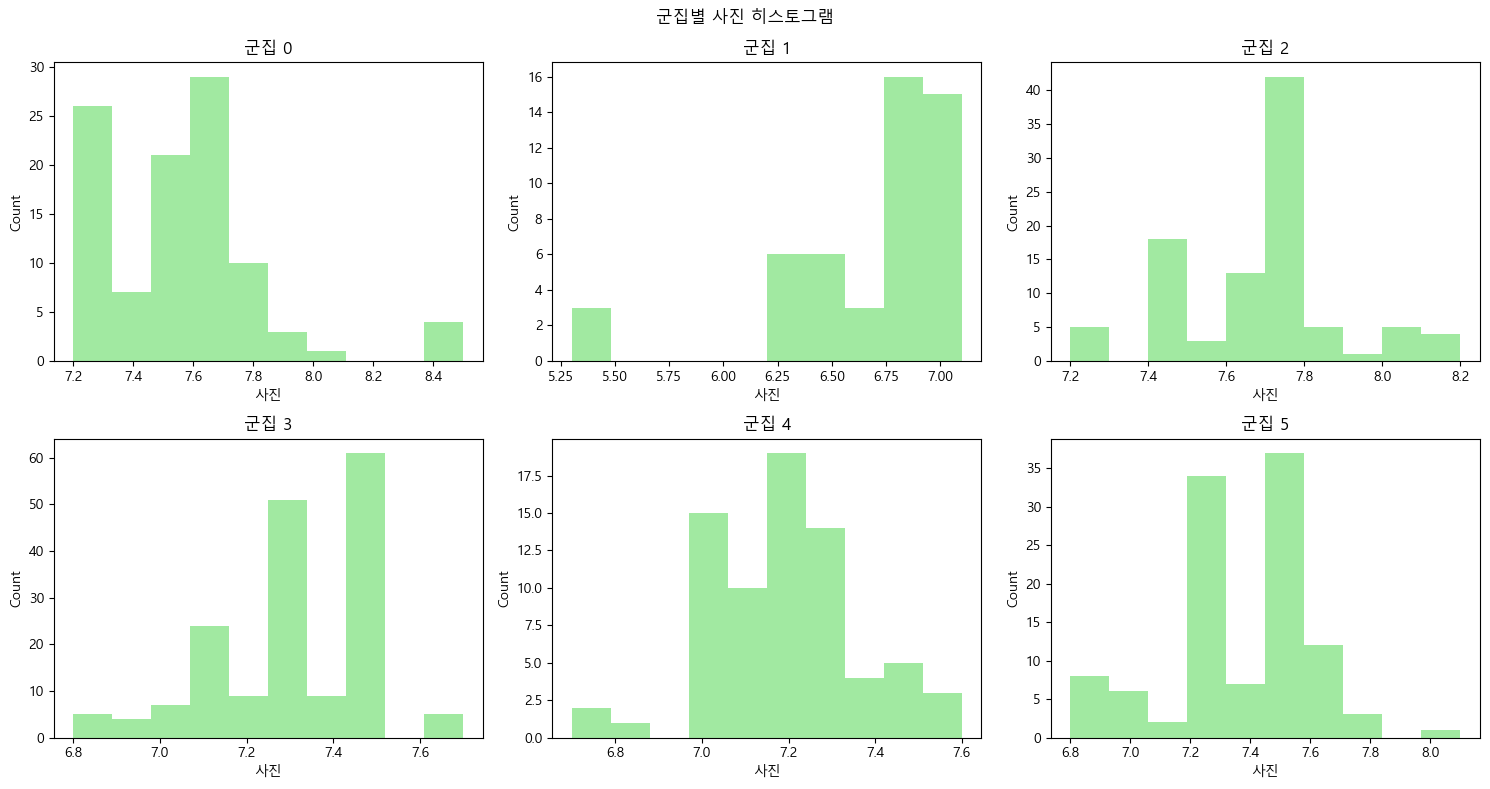

In [139]:
#------------------------------------------------------------------------
# Hist
#------------------------------------------------------------------------
histogram_by_cluster(
    cluster_list,
    value_col='사진',
    figsize=(15, 8),
    bins = 10
)

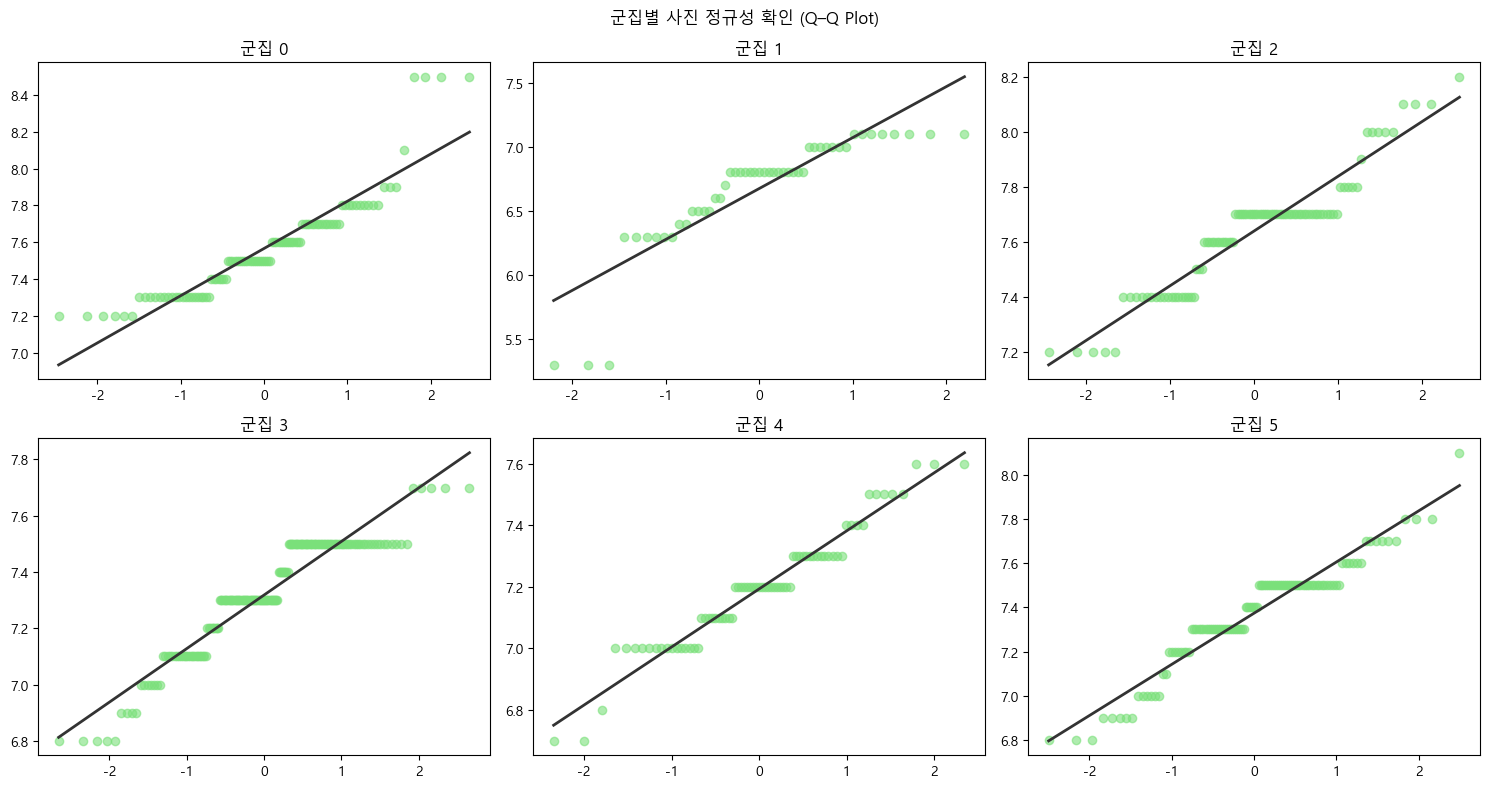

In [140]:
#------------------------------------------------------------------------
# Q - Q Plot
#------------------------------------------------------------------------

qqplot_by_cluster(
    cluster_list,
    value_col="사진",
    figsize=(15, 8),
)

In [141]:
# 사진

for i in cluster_list:
    skew_kurt(i, '사진')
    print('')

=============== 군집 0 ====================
  - 왜도(Skew): 1.4701 (적절)
  - 첨도(Kurt): 3.2073 (적절)

=============== 군집 1 ====================
  - 왜도(Skew): -1.8084 (적절)
  - 첨도(Kurt): 3.4088 (적절)

=============== 군집 2 ====================
  - 왜도(Skew): 0.0992 (적절)
  - 첨도(Kurt): 0.3960 (적절)

=============== 군집 3 ====================
  - 왜도(Skew): -0.6139 (적절)
  - 첨도(Kurt): -0.0673 (적절)

=============== 군집 4 ====================
  - 왜도(Skew): -0.0366 (적절)
  - 첨도(Kurt): 0.2677 (적절)

=============== 군집 5 ====================
  - 왜도(Skew): -0.3731 (적절)
  - 첨도(Kurt): 0.5058 (적절)



In [142]:
#------------------------------------------------------------------------
# 모수검정 시작(ANOVA)
#------------------------------------------------------------------------

welch_anova_report(df, '사진', 2)

H0 : 군집 2와 타 군집 간의 평균 사진 점수는 통계적으로 유의미한 차이가 없다.
H1 : 군집 2의 평균 사진 점수는 타 군집의 평균보다 통계적으로 유의미하게 높다.


,Source,ddof1,ddof2,F,p-unc,np2
0,군집,5,218.3645,81.7147,0.0000,0.5064


ANOVA 유의미
사후검정 고려
효과크기 : 큰 효과 (np2=0.5064)


In [143]:
#------------------------------------------------------------------------
# 효과크기 Games-Howell
#------------------------------------------------------------------------

games_howell_target_test(df, '사진', 2)

가설기각: 사진에 대해 유의하지 않거나, 높고 낮음이 혼재


,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
1,2,0,7.6385,7.5663,0.0722,0.0343,2.1031,185.5891,0.2903,0.2965
5,2,1,7.6385,6.6735,0.9651,0.0661,14.6018,59.0262,0.0000,3.1523
9,2,3,7.6385,7.3183,0.3203,0.0258,12.4071,189.4810,0.0000,1.5888
10,2,4,7.6385,7.1932,0.4454,0.0306,14.5758,160.9623,0.0000,2.2280
11,2,5,7.6385,7.3736,0.2649,0.0308,8.5955,203.9995,0.0000,1.1849


# 군집 0 (계절매력)

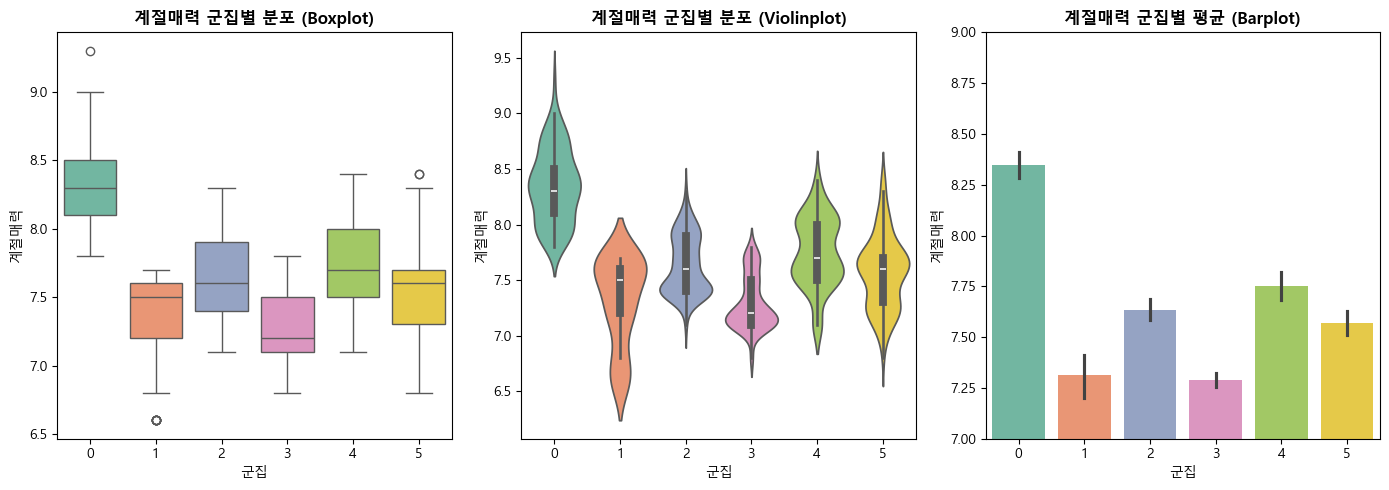

In [144]:
# ===================================================================
# H0 : 군집 0와 타 군집 간의 평균 계절매력 점수는 통계적으로 유의미한 차이가 없다.
# H1 : 군집 0의 평균 계절매력 점수는 타 군집의 평균보다 통계적으로 유의미하게 높다.
# ===================================================================

plot_cluster_distribution_triplet(
    df=df,
    value_col='계절매력',
    figsize=(14, 5),
    palette="Set2",
    bar_ylim=(7, 9)
)

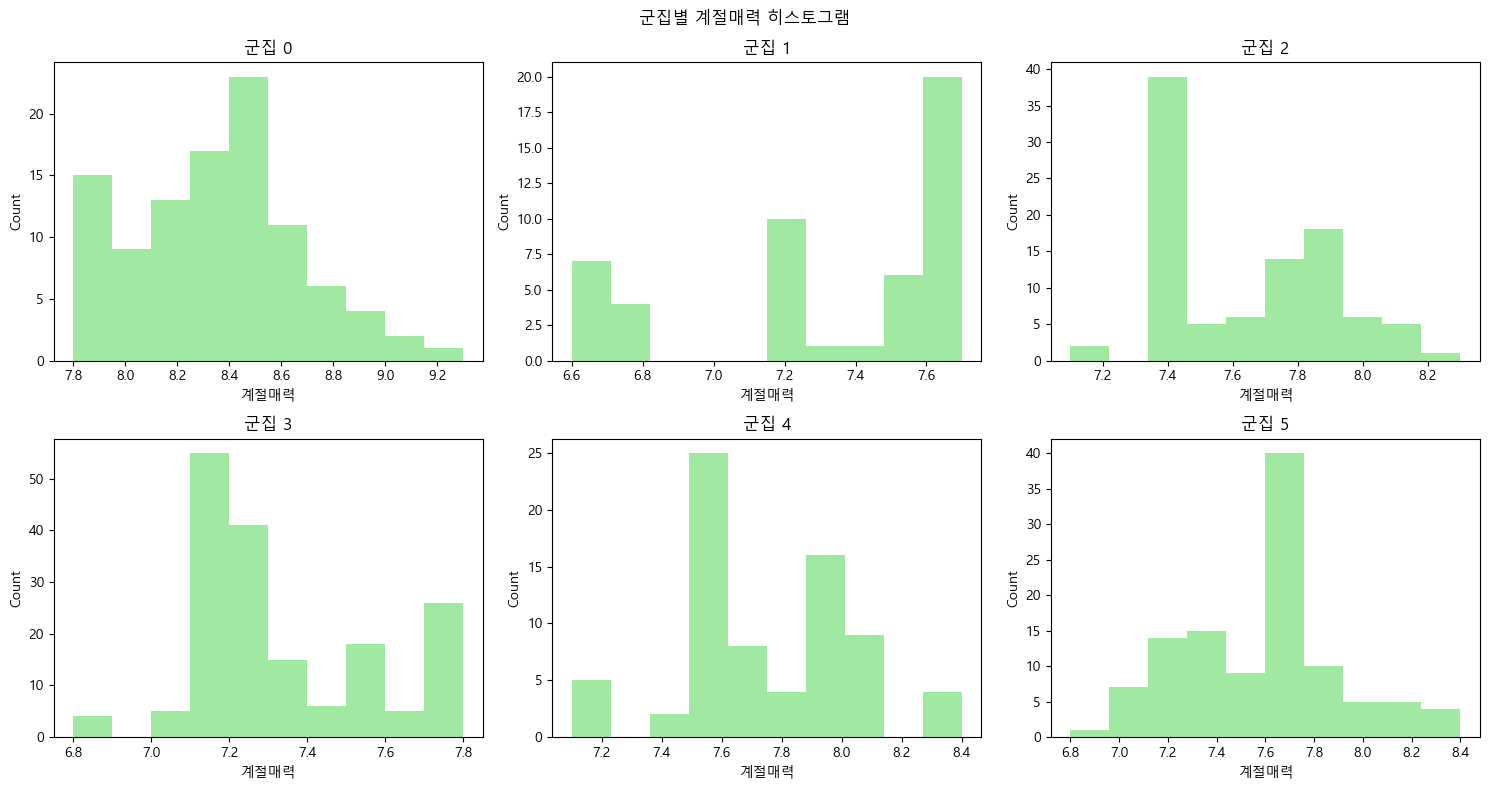

In [145]:
#------------------------------------------------------------------------
# Hist
#------------------------------------------------------------------------

histogram_by_cluster(
    cluster_list,
    value_col='계절매력',
    figsize=(15, 8),
    bins = 10
)

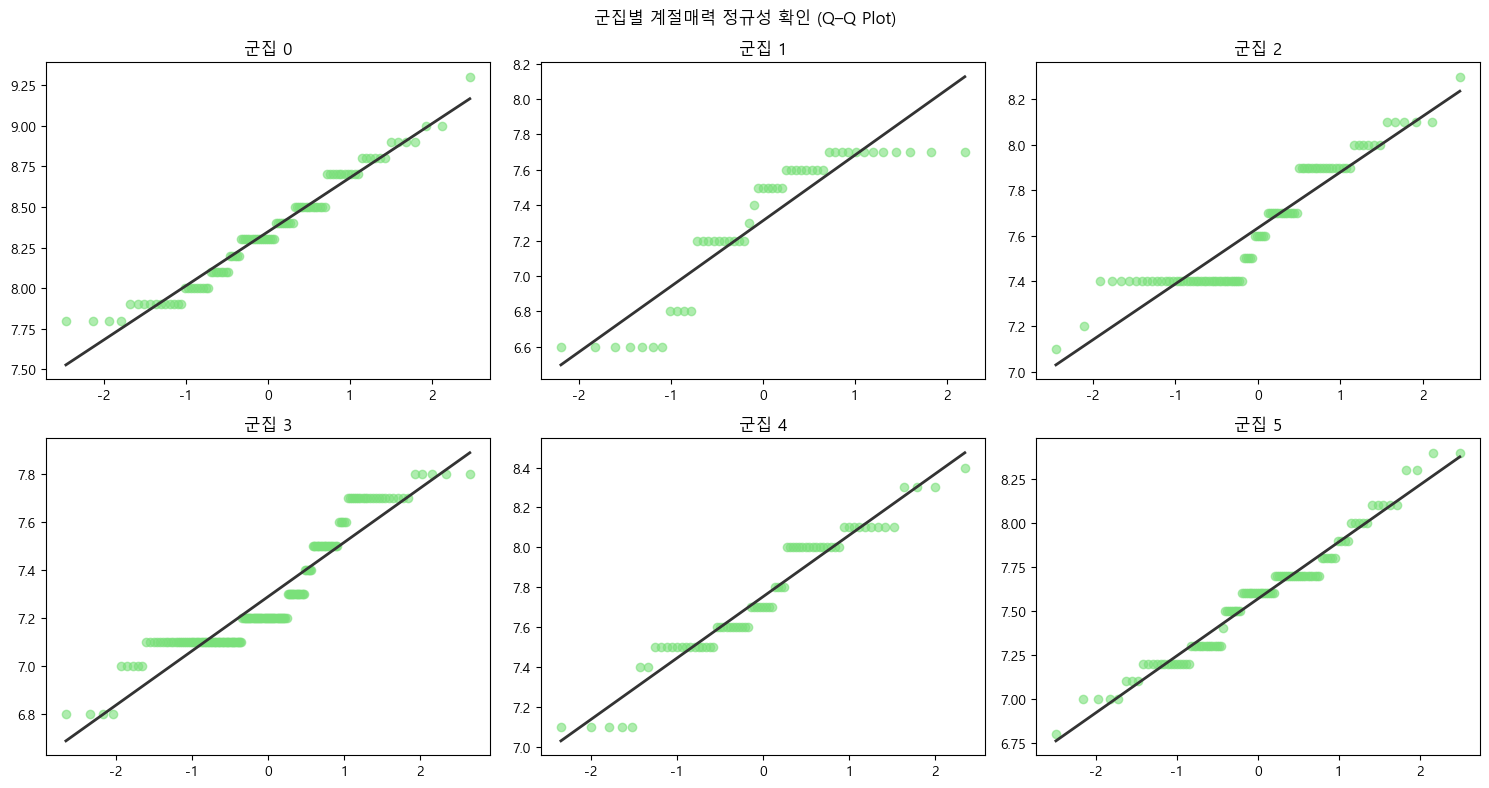

In [146]:
#------------------------------------------------------------------------
# Q - Q Plot
#------------------------------------------------------------------------

qqplot_by_cluster(
    cluster_list,
    value_col='계절매력',
    figsize=(15, 8),
)


In [147]:
# 계절매력

for i in cluster_list:
    skew_kurt(i, '계절매력')
    print('')

=============== 군집 0 ====================
  - 왜도(Skew): 0.2889 (적절)
  - 첨도(Kurt): -0.5557 (적절)

=============== 군집 1 ====================
  - 왜도(Skew): -0.7459 (적절)
  - 첨도(Kurt): -0.8490 (적절)

=============== 군집 2 ====================
  - 왜도(Skew): 0.4294 (적절)
  - 첨도(Kurt): -0.9491 (적절)

=============== 군집 3 ====================
  - 왜도(Skew): 0.6294 (적절)
  - 첨도(Kurt): -0.5562 (적절)

=============== 군집 4 ====================
  - 왜도(Skew): -0.1627 (적절)
  - 첨도(Kurt): -0.5217 (적절)

=============== 군집 5 ====================
  - 왜도(Skew): 0.2401 (적절)
  - 첨도(Kurt): -0.1470 (적절)



In [148]:
#------------------------------------------------------------------------
# 모수검정 시작(ANOVA)
#------------------------------------------------------------------------

welch_anova_report(df, '계절매력', 0)

H0 : 군집 0와 타 군집 간의 평균 계절매력 점수는 통계적으로 유의미한 차이가 없다.
H1 : 군집 0의 평균 계절매력 점수는 타 군집의 평균보다 통계적으로 유의미하게 높다.


,Source,ddof1,ddof2,F,p-unc,np2
0,군집,5,216.7764,167.3739,0.0000,0.5970


ANOVA 유의미
사후검정 고려
효과크기 : 큰 효과 (np2=0.5970)


In [149]:
#------------------------------------------------------------------------
# 효과크기 Games-Howell
#------------------------------------------------------------------------

games_howell_target_test(df, '계절매력', 0)

가설채택: 군집 0가 타 군집에 비해 계절매력 평균 점수가 통계적으로 유의미하게 높음


,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,0,1,8.3465,7.3122,1.0343,0.0652,15.8731,82.3505,0.0000,2.9134
1,0,2,8.3465,7.6333,0.7132,0.0423,16.8430,187.8623,0.0000,2.3767
2,0,3,8.3465,7.2886,1.0580,0.0377,28.0897,159.9974,0.0000,3.8176
3,0,4,8.3465,7.7521,0.5945,0.0491,12.0970,161.1011,0.0000,1.8300
4,0,5,8.3465,7.5682,0.7784,0.0453,17.1845,206.5075,0.0000,2.3621


# 군집 3 (가족, 인프라)

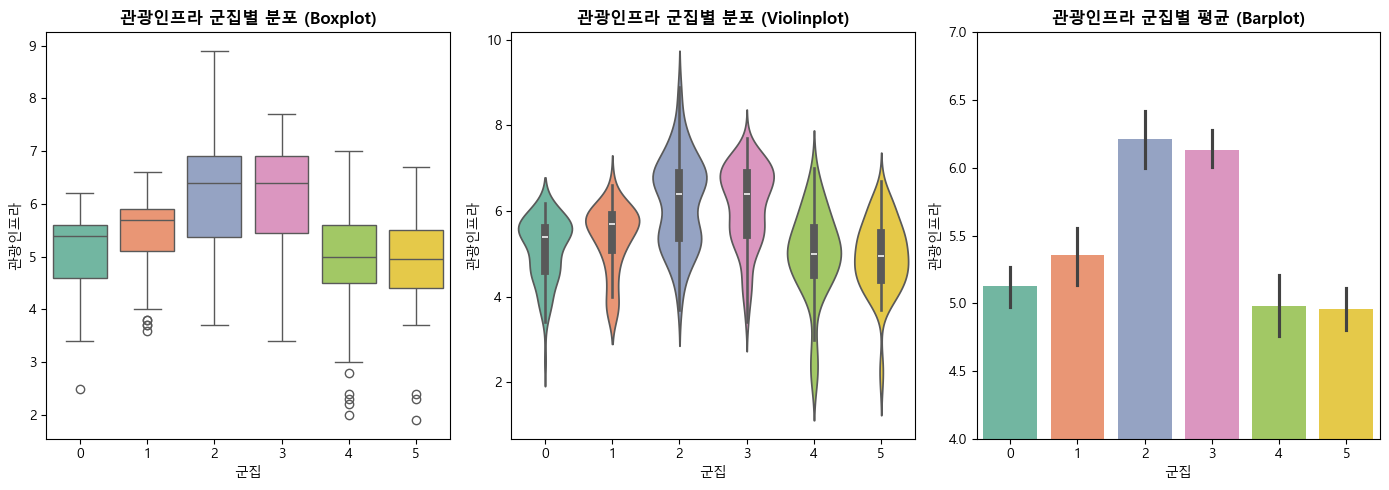

In [150]:
# ===================================================================
# H0 : 군집 3과 타 군집 간의 평균 관광인프라 점수는 통계적으로 유의미한 차이가 없다.
# H1 : 군집 3의 평균 관광인프라 점수는 타 군집의 평균보다 통계적으로 유의미하게 높다.
# ===================================================================

plot_cluster_distribution_triplet(
    df=df,
    value_col='관광인프라',
    figsize=(14, 5),
    palette="Set2",
    bar_ylim=(4, 7)
)

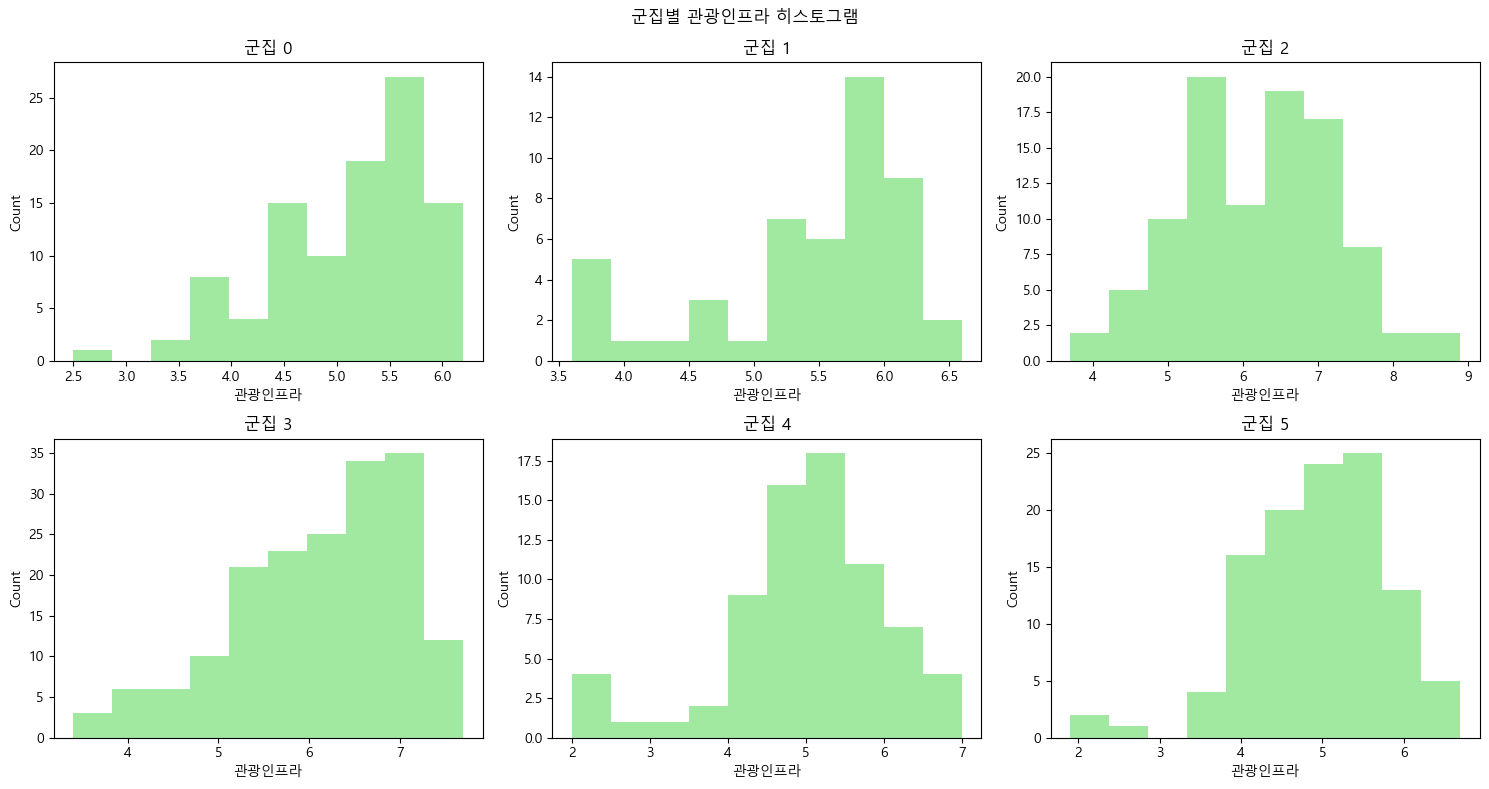

In [151]:
#------------------------------------------------------------------------
# Hist
#------------------------------------------------------------------------

histogram_by_cluster(
    cluster_list,
    value_col='관광인프라',
    figsize=(15, 8),
    bins = 10
)

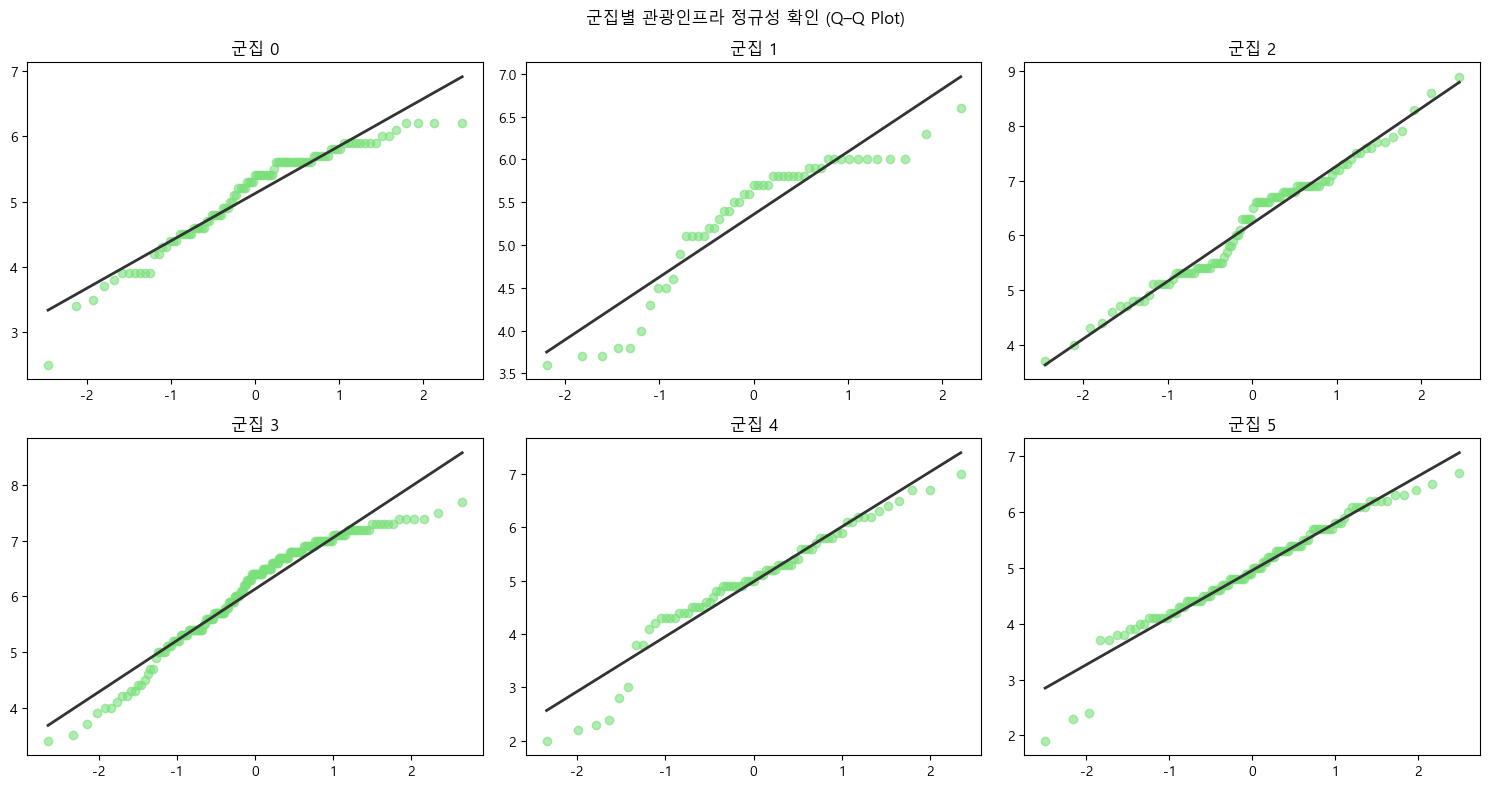

In [152]:
#------------------------------------------------------------------------
# Q - Q Plot
#------------------------------------------------------------------------

qqplot_by_cluster(
    cluster_list,
    value_col='관광인프라',
    figsize=(15, 8),
)

In [153]:
# 관광인프라

for i in cluster_list:
    skew_kurt(i, '관광인프라')
    print('')

=============== 군집 0 ====================
  - 왜도(Skew): -0.8561 (적절)
  - 첨도(Kurt): 0.4173 (적절)

=============== 군집 1 ====================
  - 왜도(Skew): -1.0012 (적절)
  - 첨도(Kurt): -0.0130 (적절)

=============== 군집 2 ====================
  - 왜도(Skew): -0.0001 (적절)
  - 첨도(Kurt): -0.4747 (적절)

=============== 군집 3 ====================
  - 왜도(Skew): -0.7449 (적절)
  - 첨도(Kurt): -0.1086 (적절)

=============== 군집 4 ====================
  - 왜도(Skew): -0.8547 (적절)
  - 첨도(Kurt): 1.0658 (적절)

=============== 군집 5 ====================
  - 왜도(Skew): -0.6504 (적절)
  - 첨도(Kurt): 1.3491 (적절)



In [154]:
#------------------------------------------------------------------------
# 모수검정 시작(ANOVA)
#------------------------------------------------------------------------

welch_anova_report(df, '관광인프라', 3)

H0 : 군집 3와 타 군집 간의 평균 관광인프라 점수는 통계적으로 유의미한 차이가 없다.
H1 : 군집 3의 평균 관광인프라 점수는 타 군집의 평균보다 통계적으로 유의미하게 높다.


,Source,ddof1,ddof2,F,p-unc,np2
0,군집,5,227.4253,42.2738,0.0000,0.2695


ANOVA 유의미
사후검정 고려
효과크기 : 큰 효과 (np2=0.2695)


In [155]:
#------------------------------------------------------------------------
# 효과크기 Games-Howell
#------------------------------------------------------------------------

games_howell_target_test(df, '관광인프라', 3)

가설기각: 관광인프라에 대해 유의하지 않거나, 높고 낮음이 혼재


,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
2,3,0,6.1331,5.1238,1.0094,0.1024,9.8560,249.4972,0.0000,1.1518
6,3,1,6.1331,5.3571,0.7760,0.1303,5.9547,93.0147,0.0000,0.8527
9,3,2,6.1331,6.2135,-0.0804,0.1288,-0.6241,178.3044,0.9891,-0.0816
12,3,4,6.1331,4.9822,1.1510,0.1412,8.1502,123.6273,0.0000,1.1796
13,3,5,6.1331,4.9555,1.1777,0.1080,10.9019,249.0456,0.0000,1.2926


In [156]:
df.groupby('군집')['관광인프라'].mean()

군집
0   5.1238
1   5.3571
2   6.2135
3   6.1331
4   4.9822
5   4.9555
Name: 관광인프라, dtype: float64

In [157]:
df.groupby('군집')['관광인프라'].median()

군집
0   5.4000
1   5.7000
2   6.4000
3   6.4000
4   5.0000
5   4.9500
Name: 관광인프라, dtype: float64

In [158]:
df.groupby('군집')['관광인프라'].agg(lambda x: x.mode().iloc[0])

군집
0   5.6000
1   6.0000
2   6.9000
3   6.8000
4   4.9000
5   4.8000
Name: 관광인프라, dtype: float64

In [159]:
df.groupby('군집')['관광인프라'].agg(std='std')

,std
군집,
0,0.7392
1,0.7638
2,1.0516
3,0.9427
4,1.0417
5,0.8515


---

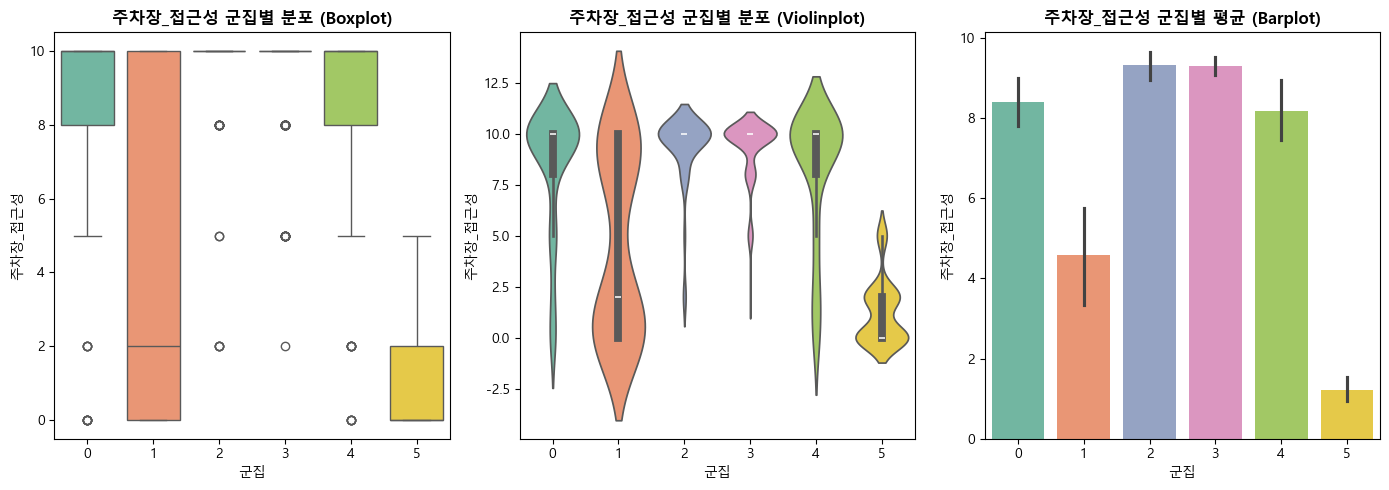

In [160]:
# ===================================================================
# H0 : 군집 3과 타 군집 간의 평균 주차장_접근성는 통계적으로 유의미한 차이가 없다.
# H1 : 군집 3의 평균 주차장_접근성는 타 군집의 평균보다 통계적으로 유의미하게 높다.
# ===================================================================

plot_cluster_distribution_triplet(
    df=df,
    value_col='주차장_접근성',
    figsize=(14, 5),
    palette="Set2",
)

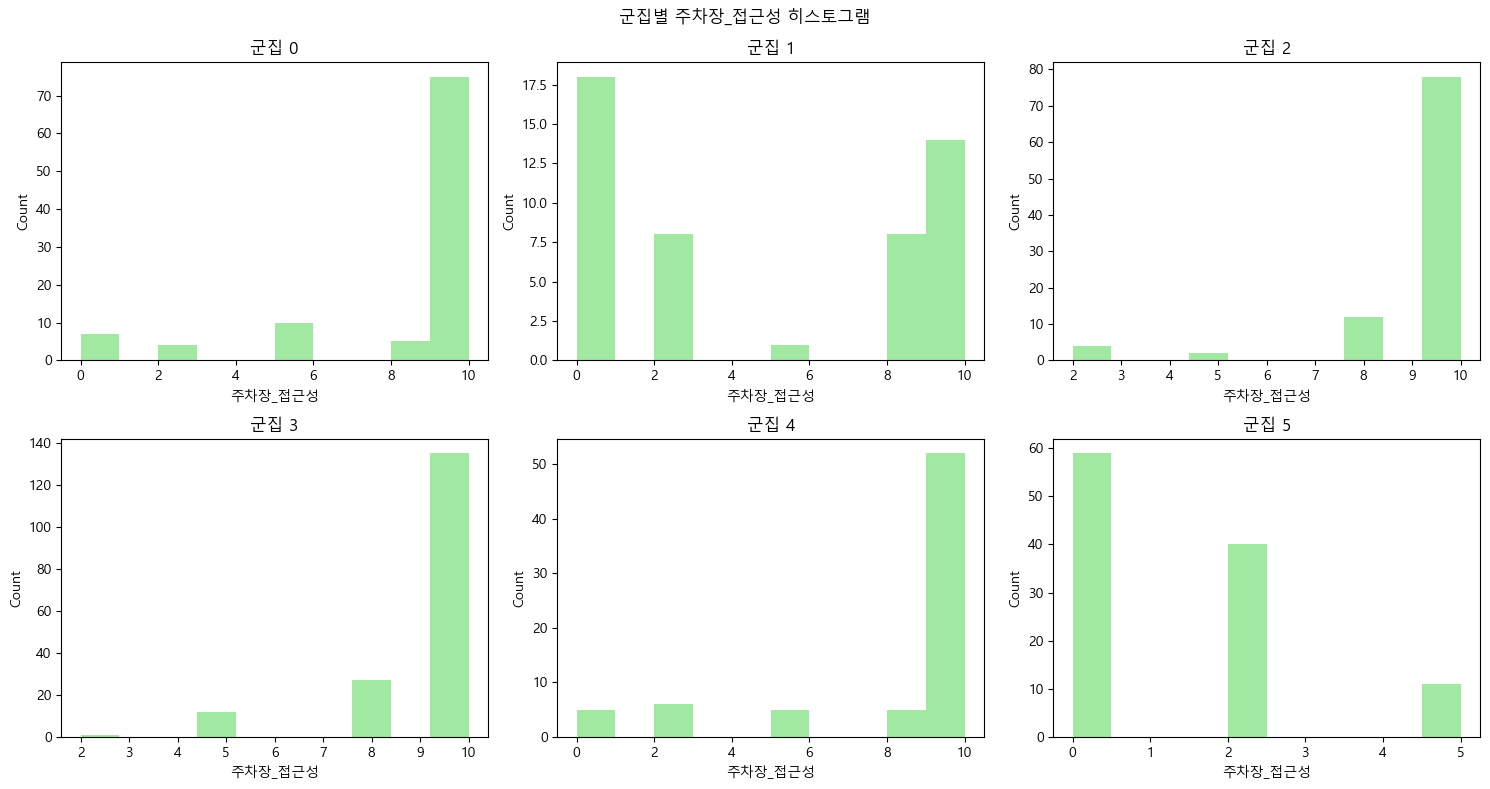

In [161]:
#------------------------------------------------------------------------
# Hist
#------------------------------------------------------------------------

histogram_by_cluster(
    cluster_list,
    value_col='주차장_접근성',
    figsize=(15, 8),
    bins = 10
)

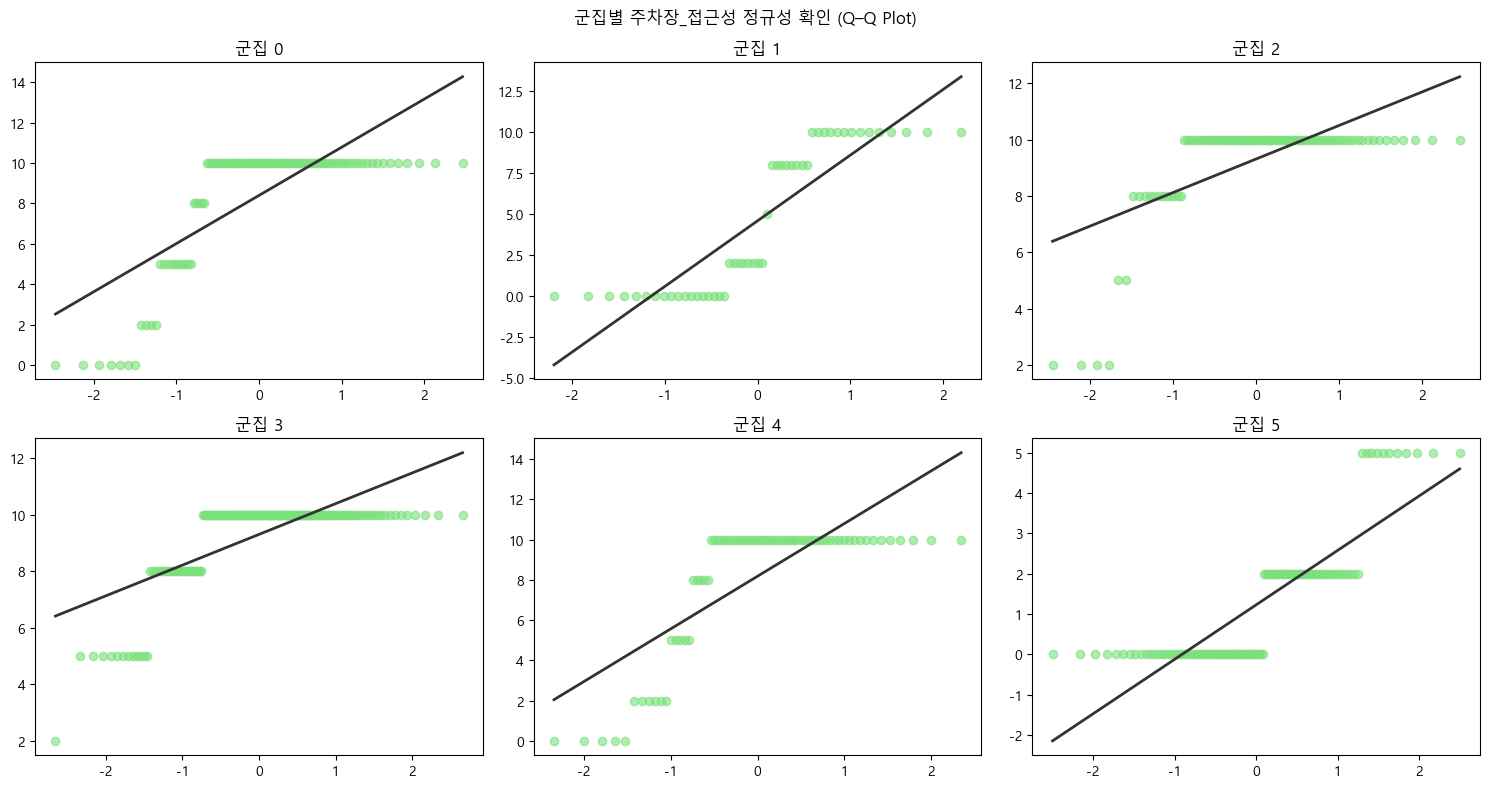

In [162]:
#------------------------------------------------------------------------
# Q - Q Plot
#------------------------------------------------------------------------

qqplot_by_cluster(
    cluster_list,
    value_col='주차장_접근성',
    figsize=(15, 8),
)

In [163]:
# 주차장_접근성

for i in cluster_list:
    skew_kurt(i, '주차장_접근성')
    print('')

=============== 군집 0 ====================
  - 왜도(Skew): -1.7643 (적절)
  - 첨도(Kurt): 1.6857 (적절)

=============== 군집 1 ====================
  - 왜도(Skew): 0.1587 (적절)
  - 첨도(Kurt): -1.8016 (적절)

=============== 군집 2 ====================
  - 왜도(Skew): -3.1196 (주의)
  - 첨도(Kurt): 9.2781 (주의)

=============== 군집 3 ====================
  - 왜도(Skew): -2.3626 (주의)
  - 첨도(Kurt): 5.2602 (적절)

=============== 군집 4 ====================
  - 왜도(Skew): -1.5472 (적절)
  - 첨도(Kurt): 0.7970 (적절)

=============== 군집 5 ====================
  - 왜도(Skew): 1.1867 (적절)
  - 첨도(Kurt): 0.6043 (적절)



In [164]:
#------------------------------------------------------------------------
# 모수검정 시작(ANOVA)
#------------------------------------------------------------------------

welch_anova_report(df, '주차장_접근성', 3)

H0 : 군집 3와 타 군집 간의 평균 주차장_접근성 점수는 통계적으로 유의미한 차이가 없다.
H1 : 군집 3의 평균 주차장_접근성 점수는 타 군집의 평균보다 통계적으로 유의미하게 높다.


,Source,ddof1,ddof2,F,p-unc,np2
0,군집,5,208.8509,415.2372,0.0000,0.6083


ANOVA 유의미
사후검정 고려
효과크기 : 큰 효과 (np2=0.6083)


In [165]:
#------------------------------------------------------------------------
# 효과크기 Games-Howell
#------------------------------------------------------------------------

games_howell_target_test(df, '주차장_접근성', 3)

가설기각: 주차장_접근성에 대해 유의하지 않거나, 높고 낮음이 혼재


,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
2,3,0,9.3029,8.3960,0.9068,0.3292,2.7547,127.0448,0.0718,0.4069
6,3,1,9.3029,4.5918,4.7110,0.6408,7.3520,51.1006,0.0000,1.9234
9,3,2,9.3029,9.3125,-0.0096,0.2158,-0.0447,166.8952,1.0000,-0.0060
12,3,4,9.3029,8.1781,1.1248,0.4030,2.7912,84.4929,0.0687,0.5134
13,3,5,9.3029,1.2273,8.0756,0.1875,43.0616,222.5898,0.0000,5.2890


In [166]:
#------------------------------------------------------------------------
# Kruskal-Wallis 
#------------------------------------------------------------------------

kruskal_vs_others_with_eta(
    df,
    value_col="주차장_접근성",
    target_cluster=3
)

비모수 검정 (Kruskal-Wallis) 결과

H-statistic = 55.997
p-value     = 0.0000000000
효과크기(η²) = 0.085


In [167]:
#------------------------------------------------------------------------
# Dunn's Test (비모수 사후검정)
# Cliff's delta
#------------------------------------------------------------------------

dunn_and_cliffs_target_only(
    df,
    value_col='주차장_접근성',
    target_cluster=3,
)


=== Dunn's Test (비모수 사후검정) 결과 ===
[주차장_접근성] / p_adjust=holm / alpha=0.05

군집 3 vs Others:
0   0.7021
1   0.0000
2   1.0000
3   1.0000
4   0.6980
5   0.0000
Name: 3, dtype: float64

=== Cliff's delta (target 포함 유의 pair만) ===


{(1, 3): (-0.597, 'large'), (3, 5): (0.99, 'large')}


=== Rank (전체 유의 pair 기반, 모든 군집 포함) ===


,Cluster,Score,Wins,Losses,Rank
0,3,1.5870,2,0,1
1,2,1.5850,2,0,2
2,0,1.3700,2,0,3
3,4,1.3280,2,0,4
4,1,-1.8250,1,4,5
5,5,-4.0450,0,5,6


In [168]:
print("평균")
df.groupby(['군집'])['주차장_접근성'].mean().sort_values(ascending=False)

평균


군집
2   9.3125
3   9.3029
0   8.3960
4   8.1781
1   4.5918
5   1.2273
Name: 주차장_접근성, dtype: float64

---

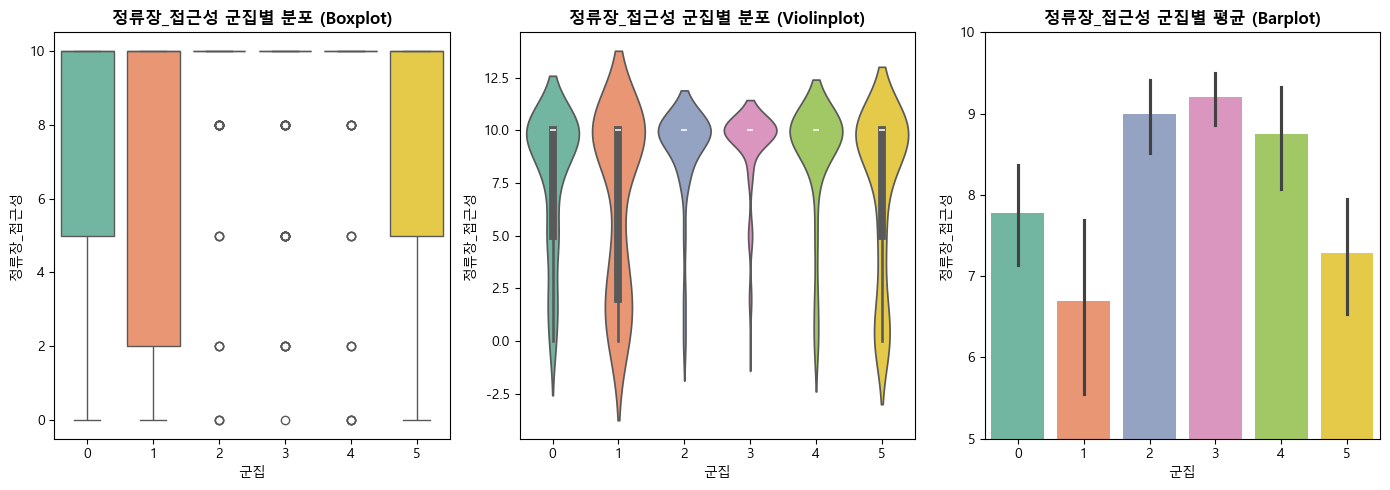

In [169]:
# ===================================================================
# H0 : 군집 3과 타 군집 간의 평균 정류장_접근성는 통계적으로 유의미한 차이가 없다.
# H1 : 군집 3의 평균 정류장_접근성는 타 군집의 평균보다 통계적으로 유의미하게 높다.
# ===================================================================

plot_cluster_distribution_triplet(
    df=df,
    value_col='정류장_접근성',
    figsize=(14, 5),
    palette="Set2",
    bar_ylim=(5, 10)
)

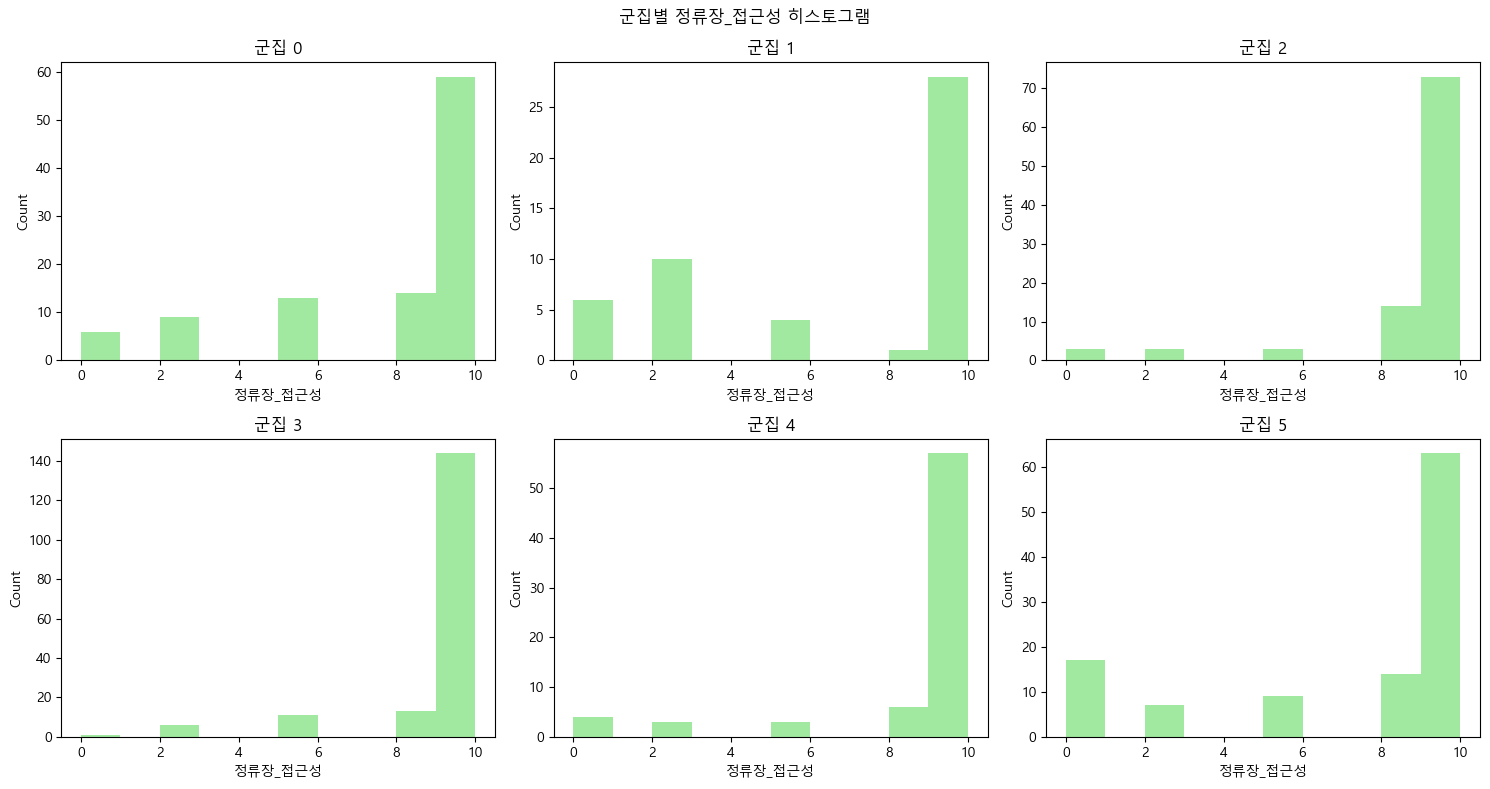

In [170]:
#------------------------------------------------------------------------
# Hist
#------------------------------------------------------------------------

histogram_by_cluster(
    cluster_list,
    value_col='정류장_접근성',
    figsize=(15, 8),
    bins = 10
)

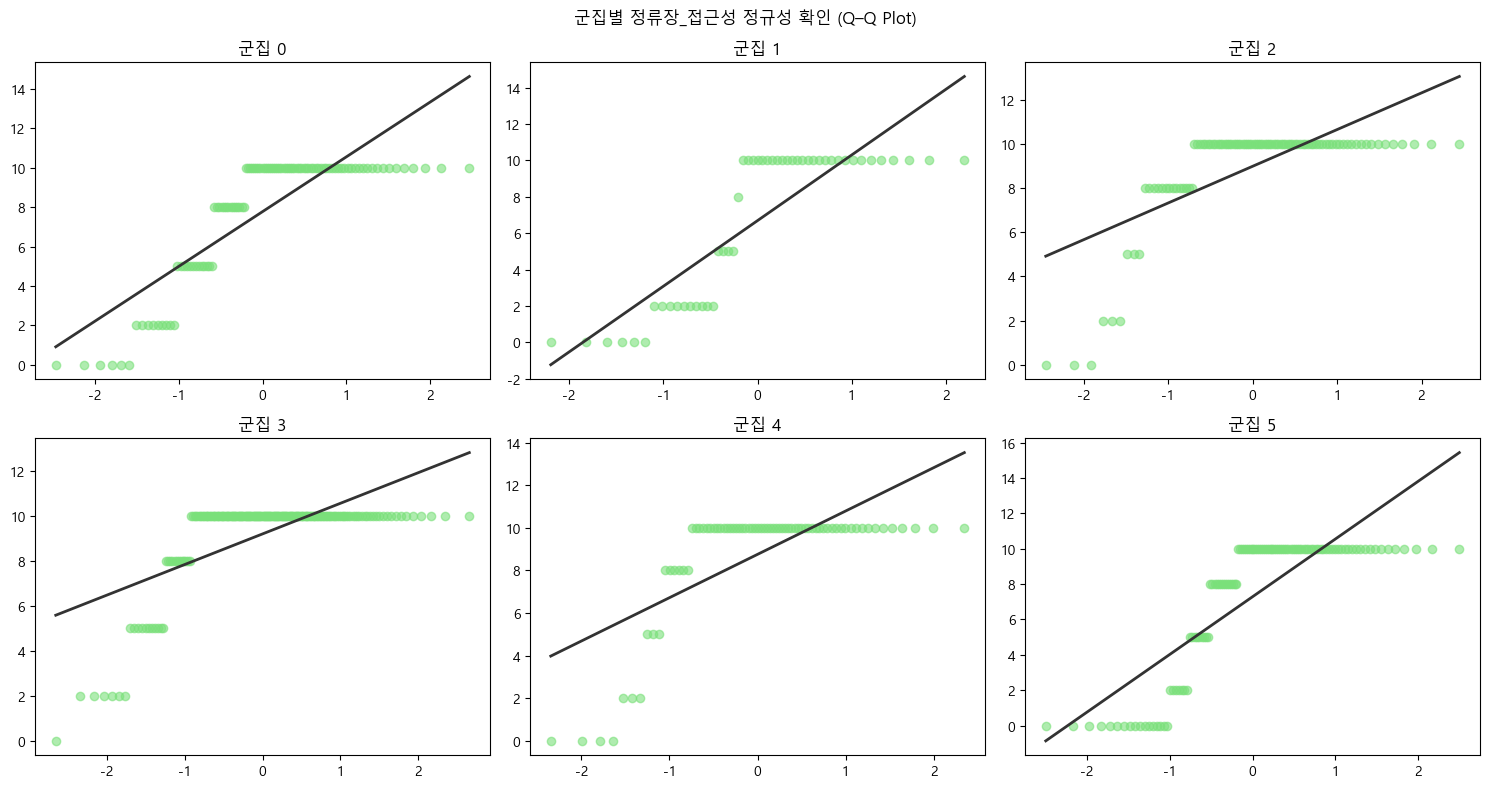

In [171]:
#------------------------------------------------------------------------
# Q - Q Plot
#------------------------------------------------------------------------

qqplot_by_cluster(
    cluster_list,
    value_col='정류장_접근성',
    figsize=(15, 8),
)

In [172]:
# 왜도, 첨도

for i in cluster_list:
    skew_kurt(i, '주차장_접근성')
    print('')

=============== 군집 0 ====================
  - 왜도(Skew): -1.7643 (적절)
  - 첨도(Kurt): 1.6857 (적절)

=============== 군집 1 ====================
  - 왜도(Skew): 0.1587 (적절)
  - 첨도(Kurt): -1.8016 (적절)

=============== 군집 2 ====================
  - 왜도(Skew): -3.1196 (주의)
  - 첨도(Kurt): 9.2781 (주의)

=============== 군집 3 ====================
  - 왜도(Skew): -2.3626 (주의)
  - 첨도(Kurt): 5.2602 (적절)

=============== 군집 4 ====================
  - 왜도(Skew): -1.5472 (적절)
  - 첨도(Kurt): 0.7970 (적절)

=============== 군집 5 ====================
  - 왜도(Skew): 1.1867 (적절)
  - 첨도(Kurt): 0.6043 (적절)



In [173]:
#------------------------------------------------------------------------
# 모수검정 시작(ANOVA)
#------------------------------------------------------------------------

welch_anova_report(df, '정류장_접근성', 3)

H0 : 군집 3와 타 군집 간의 평균 정류장_접근성 점수는 통계적으로 유의미한 차이가 없다.
H1 : 군집 3의 평균 정류장_접근성 점수는 타 군집의 평균보다 통계적으로 유의미하게 높다.


,Source,ddof1,ddof2,F,p-unc,np2
0,군집,5,212.8644,9.3635,0.0000,0.0821


ANOVA 유의미
사후검정 고려
효과크기 : 중간 효과 (np2=0.0821)


In [174]:
#------------------------------------------------------------------------
# 효과크기 Games-Howell
#------------------------------------------------------------------------

games_howell_target_test(df, '정류장_접근성', 3)

가설기각: 정류장_접근성에 대해 유의하지 않거나, 높고 낮음이 혼재


,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
2,3,0,9.2057,7.7723,1.4334,0.3571,4.0138,144.8336,0.0013,0.5646
6,3,1,9.2057,6.6939,2.5118,0.6056,4.1479,54.5739,0.0016,0.9602
9,3,2,9.2057,8.9896,0.2161,0.2839,0.7614,171.1865,0.9735,0.1010
12,3,4,9.2057,8.7534,0.4523,0.3645,1.2407,103.4310,0.8158,0.1978
13,3,5,9.2057,7.2818,1.9239,0.3973,4.8430,146.7066,0.0000,0.6706


In [175]:
#------------------------------------------------------------------------
# Kruskal-Wallis 
#------------------------------------------------------------------------

kruskal_vs_others_with_eta(
    df,
    value_col="정류장_접근성",
    target_cluster=3
)

비모수 검정 (Kruskal-Wallis) 결과

H-statistic = 19.574
p-value     = 0.0000096784
효과크기(η²) = 0.024


In [176]:
#------------------------------------------------------------------------
# Dunn's Test (비모수 사후검정)
# Cliff's delta
#------------------------------------------------------------------------

dunn_and_cliffs_target_only(
    df,
    value_col='정류장_접근성',
    target_cluster=3,
)

=== Dunn's Test (비모수 사후검정) 결과 ===
[정류장_접근성] / p_adjust=holm / alpha=0.05

군집 3 vs Others:
0   0.0004
1   0.0006
2   1.0000
3   1.0000
4   1.0000
5   0.0000
Name: 3, dtype: float64

=== Cliff's delta (target 포함 유의 pair만) ===


{(0, 3): (-0.251, 'small'), (1, 3): (-0.3, 'small'), (3, 5): (0.275, 'small')}


=== Rank (전체 유의 pair 기반, 모든 군집 포함) ===


,Cluster,Score,Wins,Losses,Rank
0,3,0.8260,3,0,1
1,2,0.6720,3,0,2
2,4,0.4590,2,0,3
3,0,-0.4500,0,2,4
4,5,-0.7180,0,3,5
5,1,-0.7890,0,3,6


# 군집 4 (힐링)

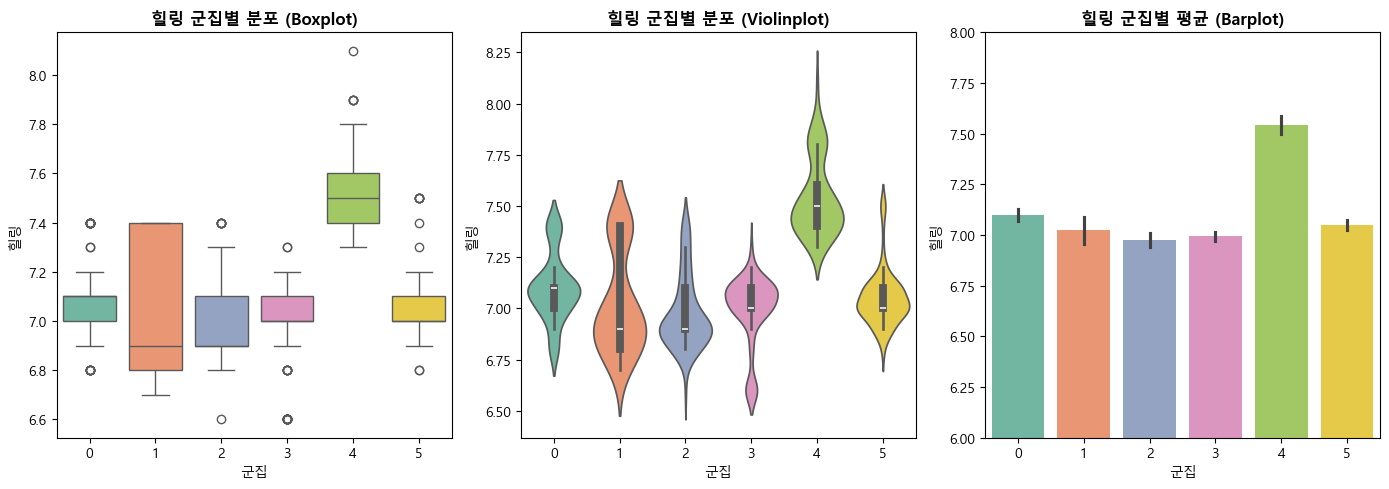

In [177]:
# ===================================================================
# H0 : 군집 4와 타 군집 간의 평균 힐링 점수는 통계적으로 유의미한 차이가 없다.
# H1 : 군집 4의 평균 힐링 점수는 타 군집의 평균보다 통계적으로 유의미하게 높다.
# ===================================================================

plot_cluster_distribution_triplet(
    df=df,
    value_col='힐링',
    figsize=(14, 5),
    palette="Set2",
    bar_ylim=(6, 8)
)

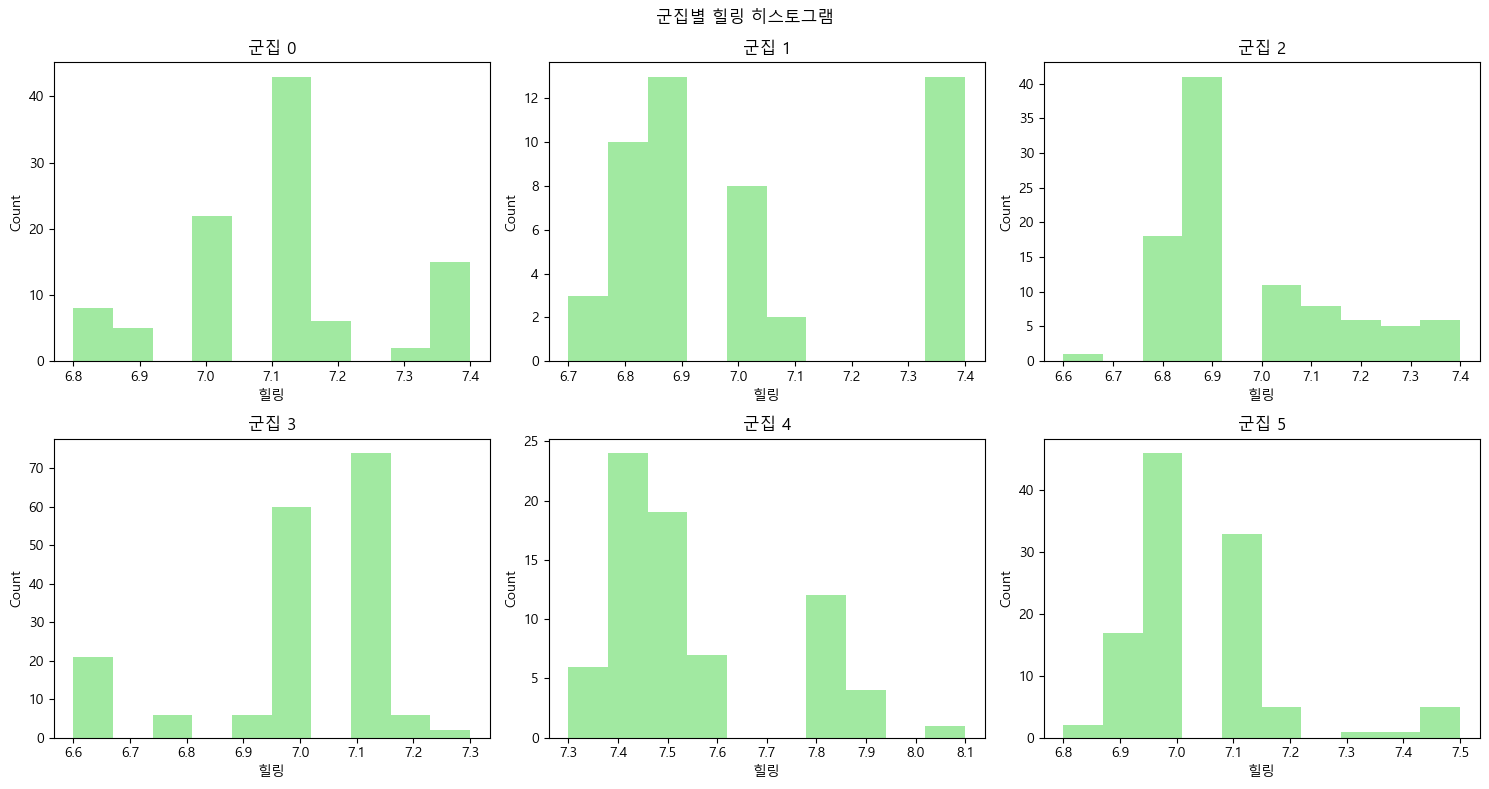

In [178]:
#------------------------------------------------------------------------
# Hist
#------------------------------------------------------------------------

histogram_by_cluster(
    cluster_list,
    value_col='힐링',
    figsize=(15, 8),
    bins = 10
)

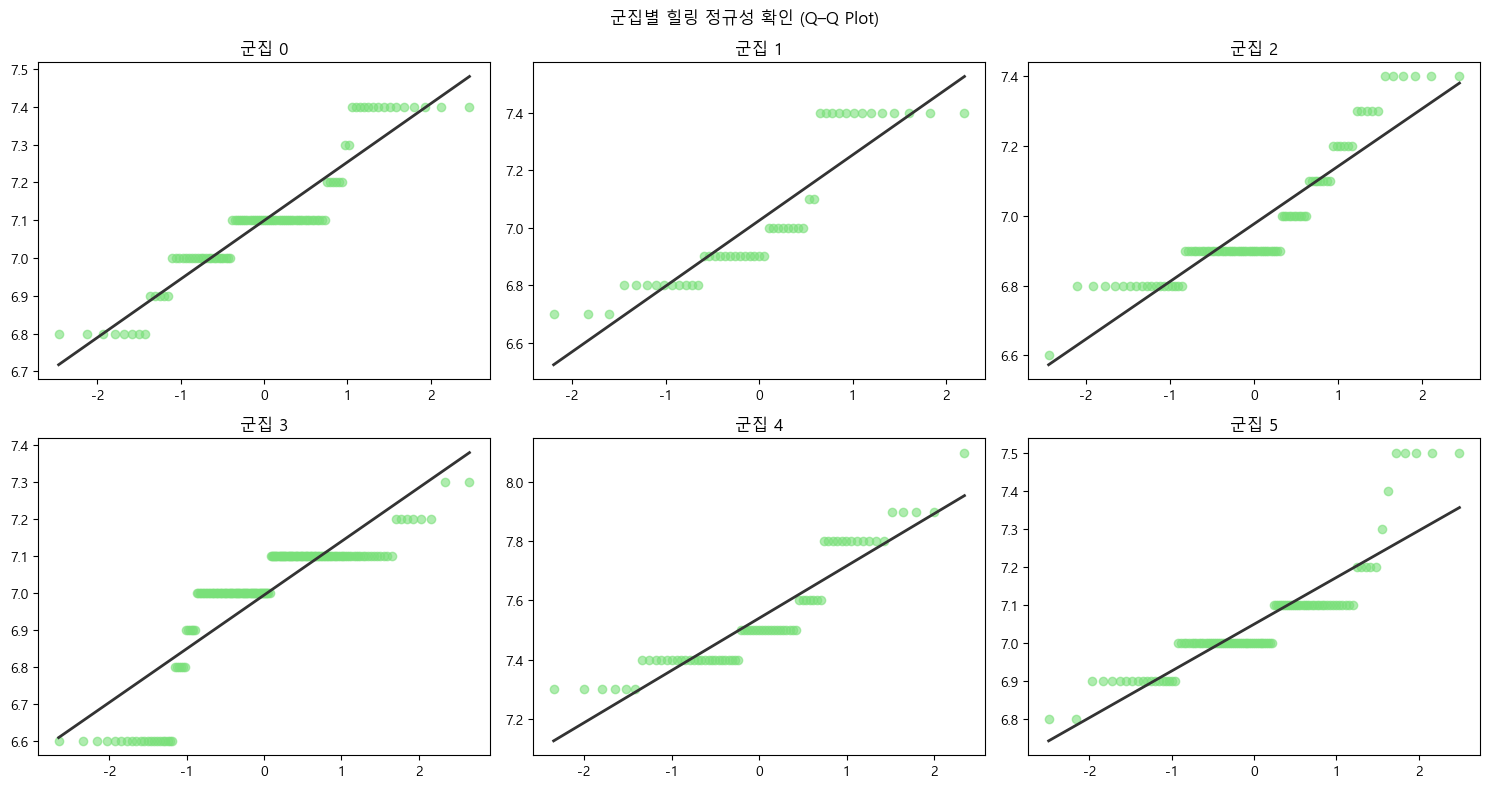

In [179]:
#------------------------------------------------------------------------
# Q - Q Plot
#------------------------------------------------------------------------

qqplot_by_cluster(
    cluster_list,
    value_col='힐링',
    figsize=(15, 8),
)

In [180]:
# 왜도, 첨도

for i in cluster_list:
    skew_kurt(i, '힐링')
    print('')

=============== 군집 0 ====================
  - 왜도(Skew): 0.3695 (적절)
  - 첨도(Kurt): -0.0662 (적절)

=============== 군집 1 ====================
  - 왜도(Skew): 0.6453 (적절)
  - 첨도(Kurt): -1.0952 (적절)

=============== 군집 2 ====================
  - 왜도(Skew): 1.0173 (적절)
  - 첨도(Kurt): 0.2911 (적절)

=============== 군집 3 ====================
  - 왜도(Skew): -1.4270 (적절)
  - 첨도(Kurt): 1.1831 (적절)

=============== 군집 4 ====================
  - 왜도(Skew): 0.9142 (적절)
  - 첨도(Kurt): -0.1131 (적절)

=============== 군집 5 ====================
  - 왜도(Skew): 1.6364 (적절)
  - 첨도(Kurt): 3.6382 (적절)



In [181]:
#------------------------------------------------------------------------
# 모수검정 시작(ANOVA)
#------------------------------------------------------------------------

welch_anova_report(df, '힐링', 4)

H0 : 군집 4와 타 군집 간의 평균 힐링 점수는 통계적으로 유의미한 차이가 없다.
H1 : 군집 4의 평균 힐링 점수는 타 군집의 평균보다 통계적으로 유의미하게 높다.


,Source,ddof1,ddof2,F,p-unc,np2
0,군집,5,219.4691,104.7648,0.0000,0.5025


ANOVA 유의미
사후검정 고려
효과크기 : 큰 효과 (np2=0.5025)


In [182]:
#------------------------------------------------------------------------
# 효과크기 Games-Howell
#------------------------------------------------------------------------

games_howell_target_test(df, '힐링', 4)

가설채택: 군집 4가 타 군집에 비해 힐링 평균 점수가 통계적으로 유의미하게 높음


,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
3,4,0,7.5397,7.0990,0.4407,0.0272,16.2137,141.5144,0.0000,2.5371
7,4,1,7.5397,7.0245,0.5152,0.0412,12.5001,84.3670,0.0000,2.4169
10,4,2,7.5397,6.9771,0.5626,0.0284,19.8420,150.5125,0.0000,3.0908
12,4,3,7.5397,6.9943,0.5454,0.0252,21.6185,121.9363,0.0000,3.1504
14,4,5,7.5397,7.0491,0.4906,0.0254,19.2962,121.5539,0.0000,3.0886


---
# 군집 5 (오지, 숨은명소)

In [183]:
#------------------------------------------------------------------------
# 모수검정 시작(ANOVA)
#------------------------------------------------------------------------

welch_anova_report(df, '주차장_접근성', 5)

H0 : 군집 5와 타 군집 간의 평균 주차장_접근성 점수는 통계적으로 유의미한 차이가 없다.
H1 : 군집 5의 평균 주차장_접근성 점수는 타 군집의 평균보다 통계적으로 유의미하게 높다.


,Source,ddof1,ddof2,F,p-unc,np2
0,군집,5,208.8509,415.2372,0.0000,0.6083


ANOVA 유의미
사후검정 고려
효과크기 : 큰 효과 (np2=0.6083)


In [184]:
#------------------------------------------------------------------------
# 효과크기 Games-Howell
#------------------------------------------------------------------------

games_howell_target_test(df, '주차장_접근성', 5)

가설채택: 군집 5가 타 군집에 비해 주차장_접근성 평균 점수가 통계적으로 유의미하게 낮음


,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
4,5,0,1.2273,8.3960,-7.1688,0.3437,-20.8584,145.1345,0.0000,-2.9379
8,5,1,1.2273,4.5918,-3.3646,0.6483,-5.1895,53.4973,0.0000,-1.2086
11,5,2,1.2273,9.3125,-8.0852,0.2373,-34.0745,190.0080,0.0000,-4.7859
13,5,3,1.2273,9.3029,-8.0756,0.1875,-43.0616,222.5898,0.0000,-5.2890
14,5,4,1.2273,8.1781,-6.9508,0.4149,-16.7533,93.8360,0.0000,-2.8657


In [185]:
#------------------------------------------------------------------------
# Kruskal-Wallis 
#------------------------------------------------------------------------

kruskal_vs_others_with_eta(
    df,
    value_col="주차장_접근성",
    target_cluster=5
)

비모수 검정 (Kruskal-Wallis) 결과

H-statistic = 262.355
p-value     = 0.0000000000
효과크기(η²) = 0.430


In [186]:
#------------------------------------------------------------------------
# Dunn's Test (비모수 사후검정)
# Cliff's delta
#------------------------------------------------------------------------

dunn_and_cliffs_target_only(
    df,
    value_col='주차장_접근성',
    target_cluster=5,
)

=== Dunn's Test (비모수 사후검정) 결과 ===
[주차장_접근성] / p_adjust=holm / alpha=0.05

군집 5 vs Others:
0   0.0000
1   0.0002
2   0.0000
3   0.0000
4   0.0000
5   1.0000
Name: 5, dtype: float64

=== Cliff's delta (target 포함 유의 pair만) ===


{(0, 5): (0.866, 'large'),
 (1, 5): (0.368, 'medium'),
 (2, 5): (0.974, 'large'),
 (3, 5): (0.99, 'large'),
 (4, 5): (0.847, 'large')}


=== Rank (전체 유의 pair 기반, 모든 군집 포함) ===


,Cluster,Score,Wins,Losses,Rank
0,3,1.5870,2,0,1
1,2,1.5850,2,0,2
2,0,1.3700,2,0,3
3,4,1.3280,2,0,4
4,1,-1.8250,1,4,5
5,5,-4.0450,0,5,6


---

In [187]:
#------------------------------------------------------------------------
# 모수검정 시작(ANOVA)
#------------------------------------------------------------------------

welch_anova_report(df, '정류장_접근성', 5)

H0 : 군집 5와 타 군집 간의 평균 정류장_접근성 점수는 통계적으로 유의미한 차이가 없다.
H1 : 군집 5의 평균 정류장_접근성 점수는 타 군집의 평균보다 통계적으로 유의미하게 높다.


,Source,ddof1,ddof2,F,p-unc,np2
0,군집,5,212.8644,9.3635,0.0000,0.0821


ANOVA 유의미
사후검정 고려
효과크기 : 중간 효과 (np2=0.0821)


In [188]:
#------------------------------------------------------------------------
# 효과크기 Games-Howell
#------------------------------------------------------------------------

games_howell_target_test(df, '정류장_접근성', 5)

가설기각: 정류장_접근성에 대해 유의하지 않거나, 높고 낮음이 혼재


,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
4,5,0,7.2818,7.7723,-0.4905,0.4892,-1.0025,207.5531,0.9167,-0.1367
8,5,1,7.2818,6.6939,0.5879,0.6917,0.8499,87.1318,0.9570,0.1489
11,5,2,7.2818,8.9896,-1.7078,0.4386,-3.8937,183.5632,0.0019,-0.5252
13,5,3,7.2818,9.2057,-1.9239,0.3973,-4.8430,146.7066,0.0000,-0.6706
14,5,4,7.2818,8.7534,-1.4716,0.4947,-2.9750,179.0333,0.0385,-0.4209


In [189]:
#------------------------------------------------------------------------
# Kruskal-Wallis 
#------------------------------------------------------------------------

kruskal_vs_others_with_eta(
    df,
    value_col="정류장_접근성",
    target_cluster=5
)

비모수 검정 (Kruskal-Wallis) 결과

H-statistic = 13.236
p-value     = 0.0002745812
효과크기(η²) = 0.014


In [190]:
#------------------------------------------------------------------------
# Dunn's Test (비모수 사후검정)
# Cliff's delta
#------------------------------------------------------------------------

dunn_and_cliffs_target_only(
    df,
    value_col='정류장_접근성',
    target_cluster=5,
)

=== Dunn's Test (비모수 사후검정) 결과 ===
[정류장_접근성] / p_adjust=holm / alpha=0.05

군집 5 vs Others:
0   1.0000
1   1.0000
2   0.0074
3   0.0000
4   0.0158
5   1.0000
Name: 5, dtype: float64

=== Cliff's delta (target 포함 유의 pair만) ===


{(2, 5): (0.224, 'small'), (3, 5): (0.275, 'small'), (4, 5): (0.219, 'small')}


=== Rank (전체 유의 pair 기반, 모든 군집 포함) ===


,Cluster,Score,Wins,Losses,Rank
0,3,0.8260,3,0,1
1,2,0.6720,3,0,2
2,4,0.4590,2,0,3
3,0,-0.4500,0,2,4
4,5,-0.7180,0,3,5
5,1,-0.7890,0,3,6
